# PulseIQ — Exploratory Data Analysis
### Module 1 | EDA
**Dataset:** Olist Brazilian E-Commerce

---

## 1. Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import STL, seasonal_decompose
import matplotlib.dates as mdates

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


---
## 2. Load & Inspect the Dataset

In [4]:
df_raw = pd.read_csv('DATASET.csv')

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape: 118,434 rows × 30 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [5]:
# Column overview
print('=== COLUMN INFO ===')
df_raw.info()


=== COLUMN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   customer_unique_id             118434 non-null  object 
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  object 
 11  customer_state                 118434 non-null  object 
 12  order_item

In [6]:
# Statistical summary
df_raw.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,118434.000000,35034.264392,29819.290218,1003.000000,11310.000000,24240.000000,58464.500000,99990.000000
order_item_id,117604.000000,1.195920,0.697721,1.000000,1.000000,1.000000,1.000000,21.000000
price,117604.000000,120.822849,184.477367,0.850000,39.900000,74.900000,134.900000,6735.000000
freight_value,117604.000000,20.045551,15.861351,0.000000,13.080000,16.290000,21.190000,409.680000
payment_sequential,118431.000000,1.094207,0.728290,1.000000,1.000000,1.000000,1.000000,29.000000
payment_installments,118431.000000,2.937398,2.774164,0.000000,1.000000,2.000000,4.000000,24.000000
payment_value,118431.000000,172.849395,268.259831,0.000000,60.860000,108.200000,189.245000,13664.080000
product_name_lenght,115906.000000,48.767208,10.035162,5.000000,42.000000,52.000000,57.000000,76.000000
product_description_lenght,115906.000000,786.957302,653.029009,4.000000,347.000000,601.000000,985.000000,3992.000000
product_photos_qty,115906.000000,2.207849,1.719519,1.000000,1.000000,1.000000,3.000000,20.000000


---
## 3. Data Cleaning & Type Fixing

In [7]:
df = df_raw.copy()

# Fixed typo in column name
df.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
}, inplace=True)

# Parsed datetime columns
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Droped rows with no price/item info
df.dropna(subset=['price', 'order_item_id'], inplace=True)

# Handled split payments: keep one row per order_id + order_item_id
df.drop_duplicates(subset=['order_id', 'order_item_id', 'product_id'], inplace=True)

# Filled missing product category
df['product_category_name'].fillna('unknown', inplace=True)

# Removed 'not_defined' payment type
df = df[df['payment_type'] != 'not_defined']

# Filtered to only delivered orders for analysis
df_delivered = df[df['order_status'] == 'delivered'].copy()

# Derived useful columns
df_delivered['total_order_value'] = df_delivered['price'] + df_delivered['freight_value']
df_delivered['delivery_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']
).dt.days
df_delivered['estimated_days'] = (
    df_delivered['order_estimated_delivery_date'] - df_delivered['order_purchase_timestamp']
).dt.days
df_delivered['delivery_delay'] = df_delivered['delivery_days'] - df_delivered['estimated_days']
df_delivered['order_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')
df_delivered['order_year'] = df_delivered['order_purchase_timestamp'].dt.year
df_delivered['order_dow'] = df_delivered['order_purchase_timestamp'].dt.day_name()
df_delivered['order_hour'] = df_delivered['order_purchase_timestamp'].dt.hour

# Filled missing product dimension/metadata columns with median
for col in ['product_name_length', 'product_description_length', 'product_photos_qty',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    df_delivered[col].fillna(df_delivered[col].median(), inplace=True)

# Droped rows where delivery date is still missing
df_delivered.dropna(subset=['order_delivered_customer_date', 'order_approved_at'], inplace=True)

# Recalculated derived columns after dropping
df_delivered['delivery_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']
).dt.days
df_delivered['delivery_delay'] = df_delivered['delivery_days'] - df_delivered['estimated_days']

print(f'Remaining nulls: {df_delivered.isnull().sum().sum()}')

print(f'Cleaned dataset shape: {df_delivered.shape[0]:,} rows × {df_delivered.shape[1]} columns')

Remaining nulls: 13
Cleaned dataset shape: 110,174 rows × 38 columns


---
## 4. Missing Value Analysis

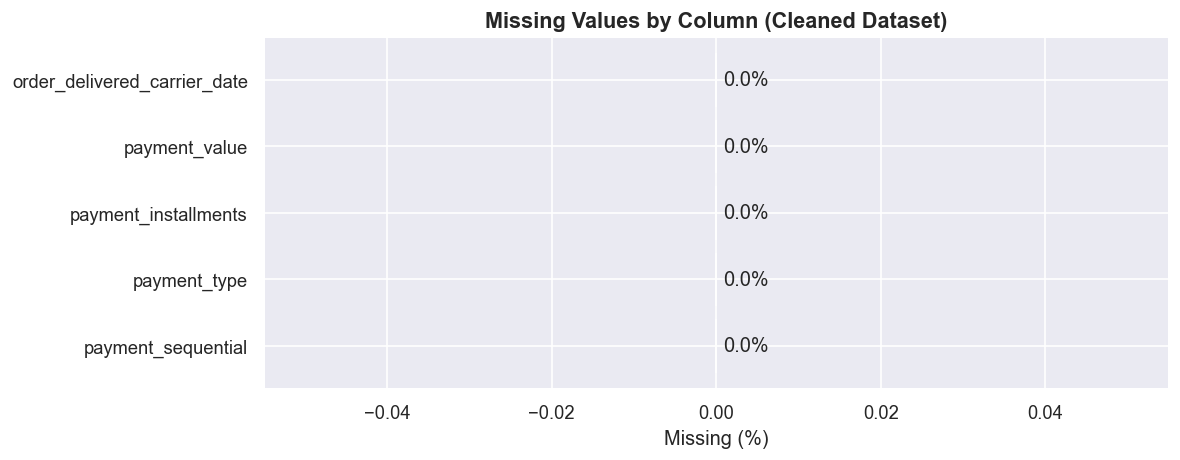

,Missing Count,Missing %
payment_sequential,3,0.0
payment_type,3,0.0
payment_installments,3,0.0
payment_value,3,0.0
order_delivered_carrier_date,1,0.0


In [8]:
missing = df_delivered.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_delivered) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing_pct, color=sns.color_palette('Reds_r', len(missing)))
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in missing_pct], padding=4)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column (Cleaned Dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

---
## 5. Univariate Analysis — Numerical Features

### 5.1 Price Distribution

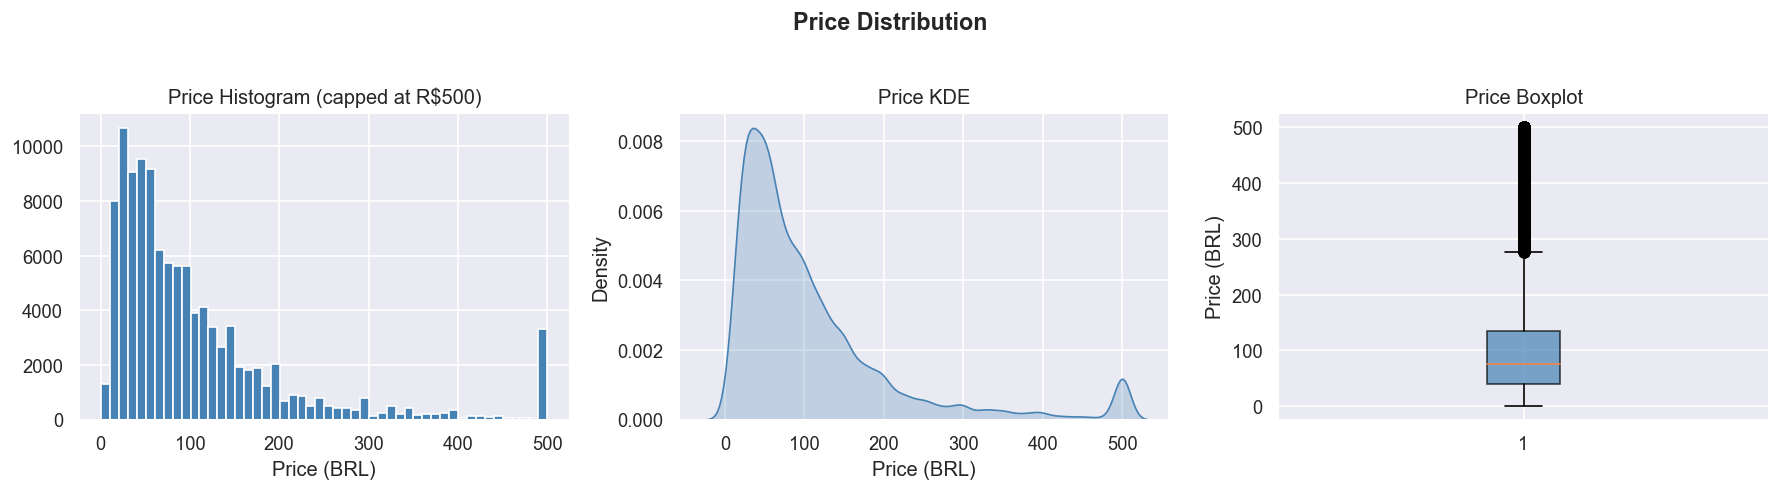

count    110174.00
mean        119.98
std         182.31
min           0.85
25%          39.90
50%          74.90
75%         134.17
max        6735.00
Name: price, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df_delivered['price'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Histogram (capped at R$500)')
axes[0].set_xlabel('Price (BRL)')

# KDE
sns.kdeplot(df_delivered['price'].clip(upper=500), ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('Price KDE')
axes[1].set_xlabel('Price (BRL)')

# Boxplot
axes[2].boxplot(df_delivered['price'].clip(upper=500), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[2].set_title('Price Boxplot')
axes[2].set_ylabel('Price (BRL)')

plt.suptitle('Price Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(df_delivered['price'].describe().round(2))

### 5.2 Freight Value Distribution

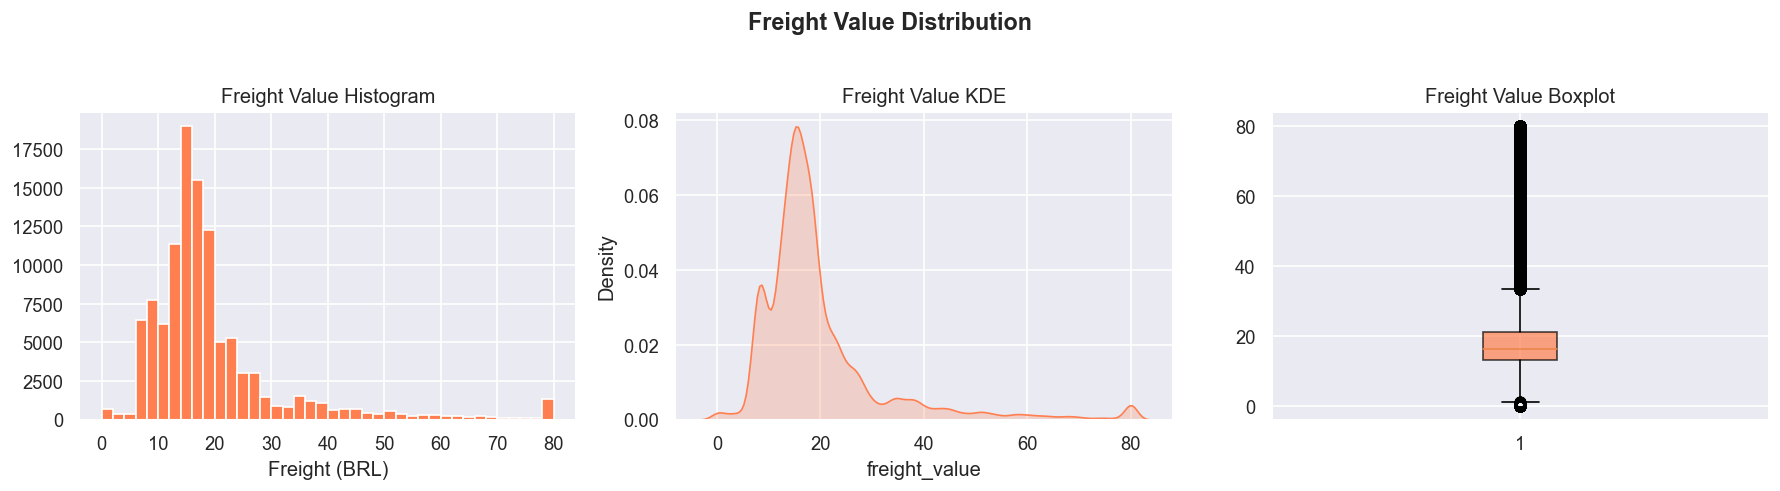

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_delivered['freight_value'].clip(upper=80), bins=40, color='coral', edgecolor='white')
axes[0].set_title('Freight Value Histogram')
axes[0].set_xlabel('Freight (BRL)')

sns.kdeplot(df_delivered['freight_value'].clip(upper=80), ax=axes[1], fill=True, color='coral')
axes[1].set_title('Freight Value KDE')

axes[2].boxplot(df_delivered['freight_value'].clip(upper=80), patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7))
axes[2].set_title('Freight Value Boxplot')

plt.suptitle('Freight Value Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Delivery Days Distribution

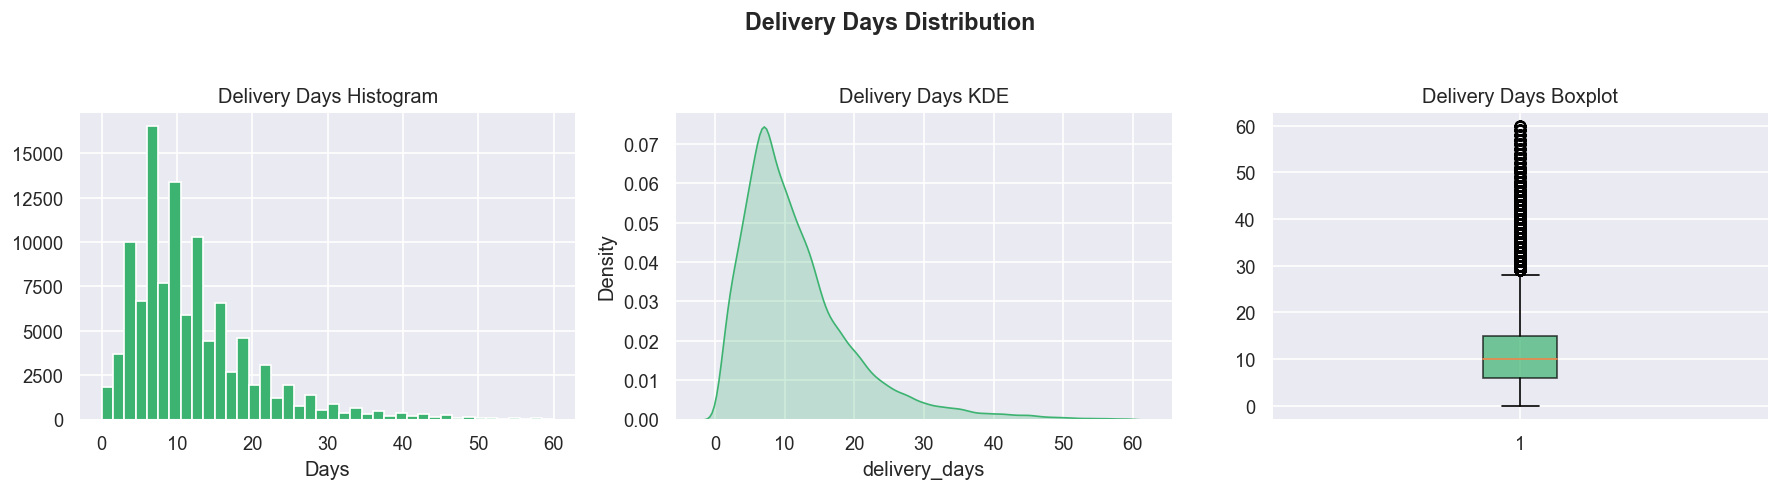

count    109863.00
mean         11.79
std           8.35
min           0.00
25%           6.00
50%          10.00
75%          15.00
max          60.00
Name: delivery_days, dtype: float64


In [11]:
del_clean = df_delivered['delivery_days'].dropna()
del_clean = del_clean[(del_clean >= 0) & (del_clean <= 60)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(del_clean, bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Delivery Days Histogram')
axes[0].set_xlabel('Days')

sns.kdeplot(del_clean, ax=axes[1], fill=True, color='mediumseagreen')
axes[1].set_title('Delivery Days KDE')

axes[2].boxplot(del_clean, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.7))
axes[2].set_title('Delivery Days Boxplot')

plt.suptitle('Delivery Days Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(del_clean.describe().round(2))

### 5.4 Payment Value Distribution

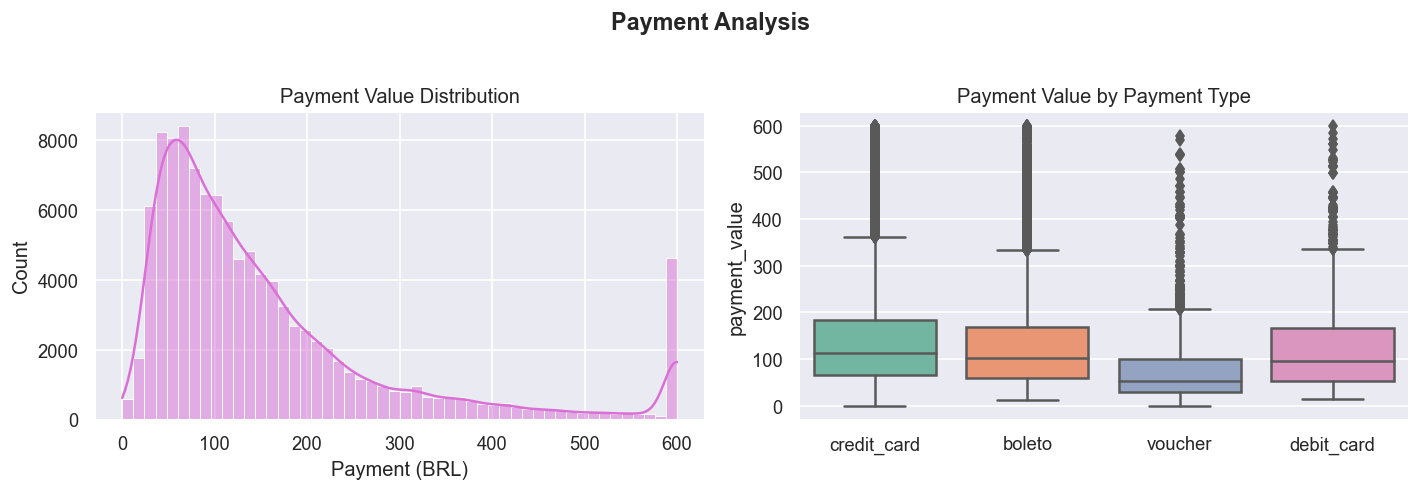

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_delivered['payment_value'].clip(upper=600), bins=50, ax=axes[0], color='orchid', kde=True)
axes[0].set_title('Payment Value Distribution')
axes[0].set_xlabel('Payment (BRL)')

sns.boxplot(x='payment_type', y='payment_value', data=df_delivered[df_delivered['payment_value'] < 600],
            ax=axes[1], palette='Set2')
axes[1].set_title('Payment Value by Payment Type')
axes[1].set_xlabel('')

plt.suptitle('Payment Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Univariate Analysis — Categorical Features

### 6.1 Order Status Distribution

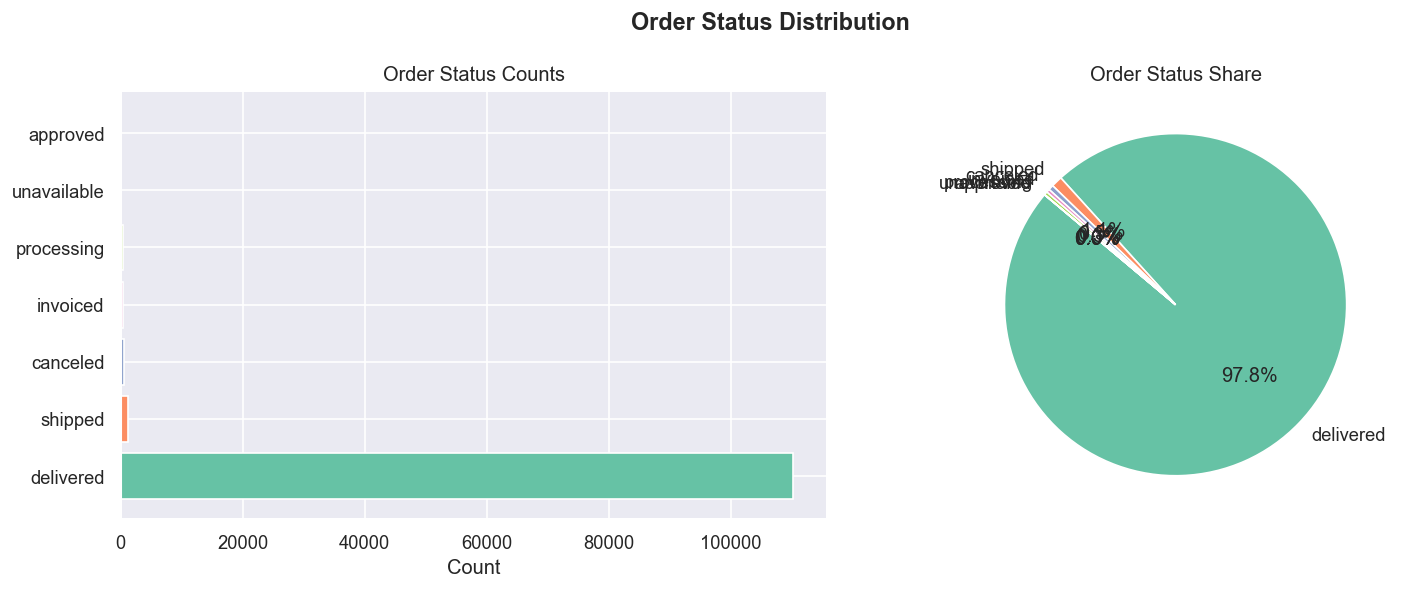

In [13]:
status_counts = df['order_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(status_counts.index, status_counts.values,
             color=sns.color_palette('Set2', len(status_counts)))
axes[0].set_title('Order Status Counts')
axes[0].set_xlabel('Count')

axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(status_counts)), startangle=140)
axes[1].set_title('Order Status Share')

plt.suptitle('Order Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Top Product Categories

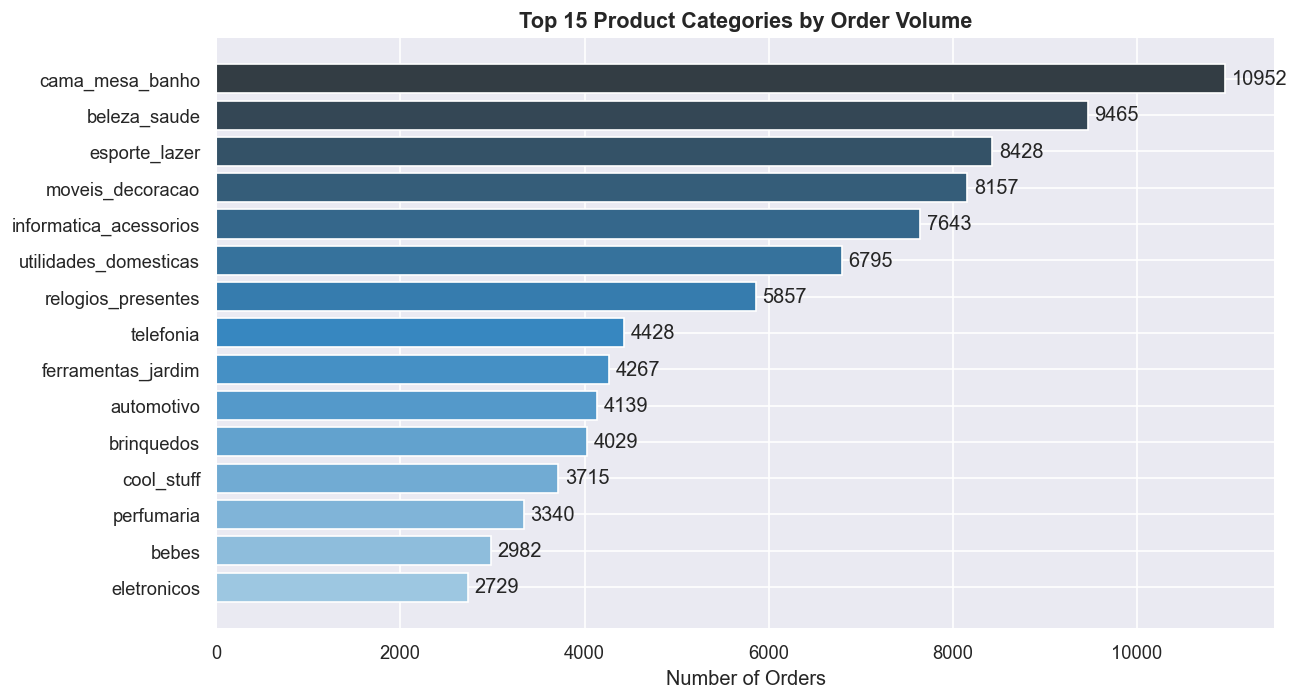

In [14]:
top_cats = df_delivered['product_category_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1],
               color=sns.color_palette('Blues_d', 15))
ax.bar_label(bars, padding=4)
ax.set_xlabel('Number of Orders')
ax.set_title('Top 15 Product Categories by Order Volume', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Payment Type Distribution

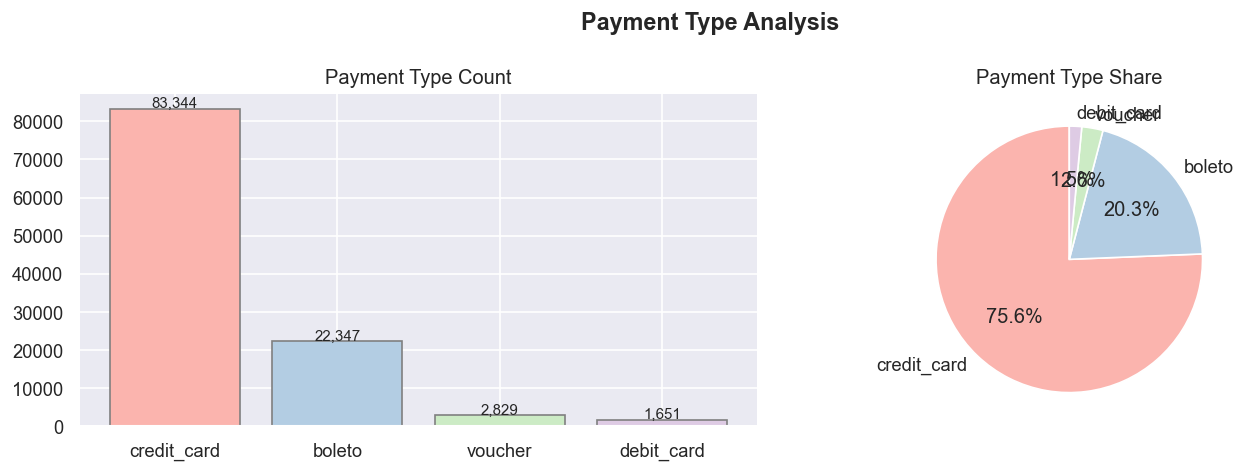

In [15]:
pay_counts = df_delivered['payment_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(pay_counts.index, pay_counts.values,
            color=sns.color_palette('Pastel1', len(pay_counts)), edgecolor='gray')
axes[0].set_title('Payment Type Count')
for i, v in enumerate(pay_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Pastel1', len(pay_counts)), startangle=90)
axes[1].set_title('Payment Type Share')

plt.suptitle('Payment Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Orders by Customer State (Top 15)

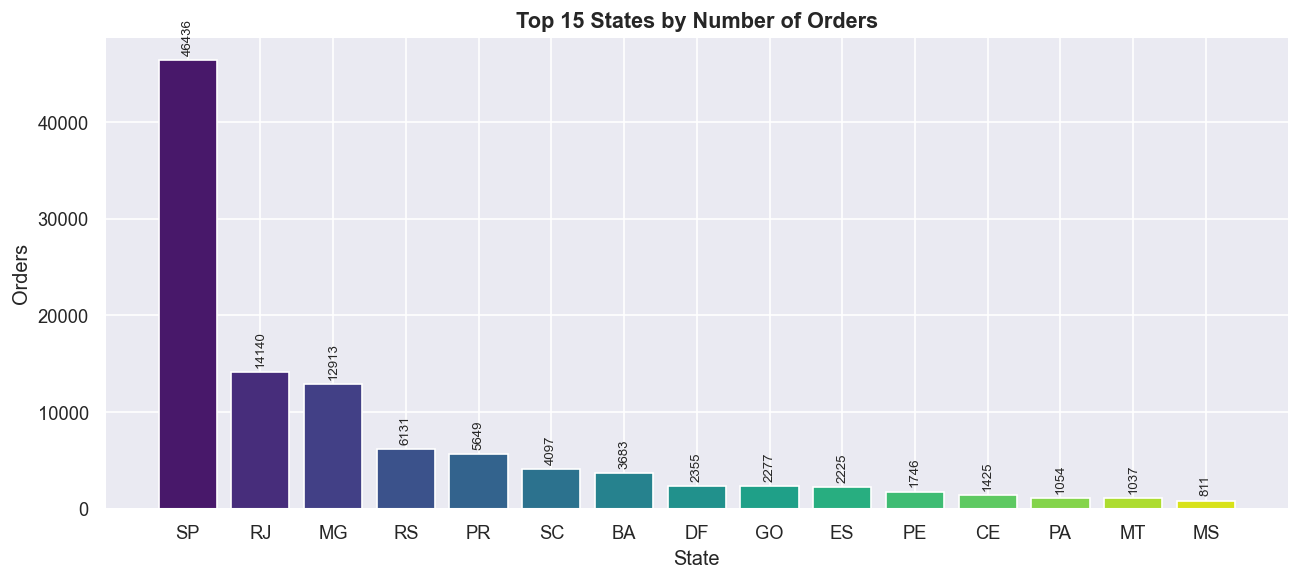

In [16]:
state_counts = df_delivered['customer_state'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(state_counts.index, state_counts.values,
              color=sns.color_palette('viridis', 15), edgecolor='white')
ax.bar_label(bars, rotation=90, padding=3, fontsize=8)
ax.set_title('Top 15 States by Number of Orders', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Orders')
plt.tight_layout()
plt.show()

---
## 7. Bivariate Analysis

### 7.1 Price vs Freight Value (Scatter Plot)

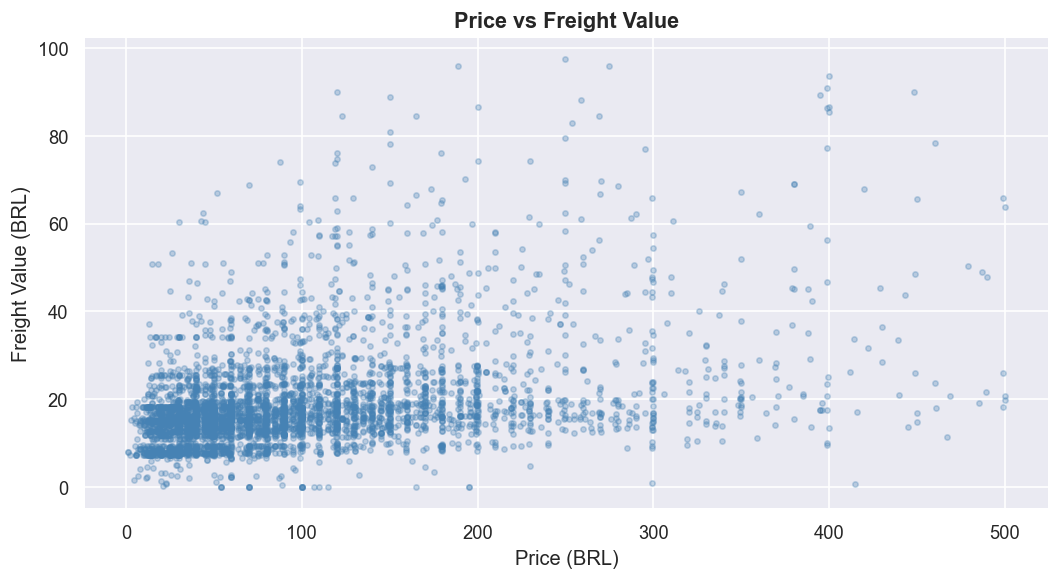

In [17]:
sample = df_delivered[['price','freight_value']].dropna().sample(5000, random_state=42)
sample = sample[(sample['price'] < 500) & (sample['freight_value'] < 100)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['price'], sample['freight_value'], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Price (BRL)')
ax.set_ylabel('Freight Value (BRL)')
ax.set_title('Price vs Freight Value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Avg Order Value by Product Category (Grouped Bar)

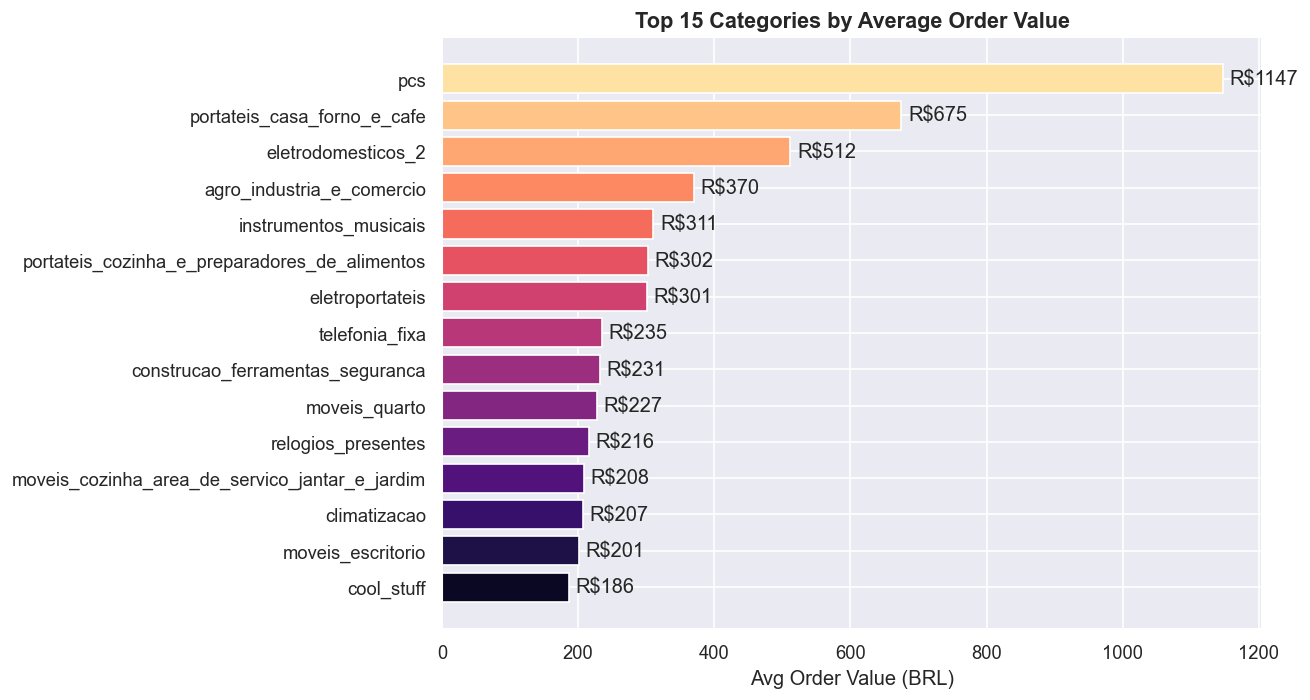

In [18]:
cat_revenue = (df_delivered.groupby('product_category_name')['total_order_value']
               .mean().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(cat_revenue.index[::-1], cat_revenue.values[::-1],
               color=sns.color_palette('magma', 15))
ax.bar_label(bars, labels=[f'R${v:.0f}' for v in cat_revenue.values[::-1]], padding=4)
ax.set_xlabel('Avg Order Value (BRL)')
ax.set_title('Top 15 Categories by Average Order Value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Delivery Days by State (Top 10 States)

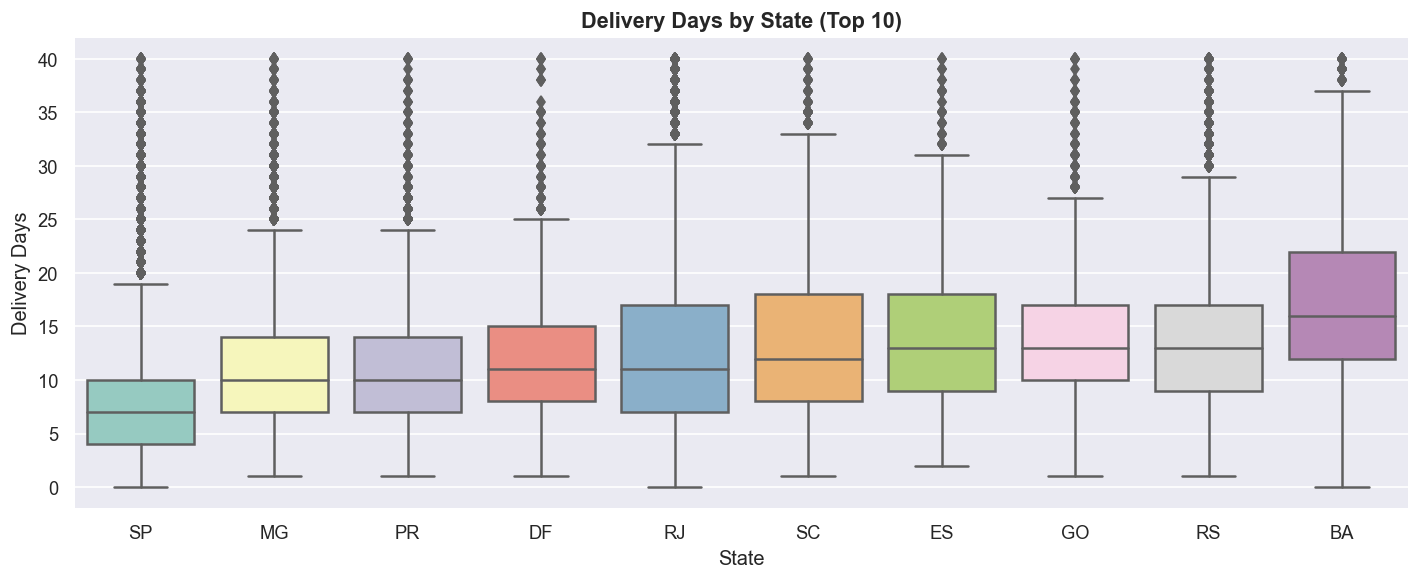

In [19]:
top_states = df_delivered['customer_state'].value_counts().head(10).index
del_by_state = df_delivered[df_delivered['customer_state'].isin(top_states)]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=del_by_state[del_by_state['delivery_days'].between(0, 40)],
            x='customer_state', y='delivery_days', palette='Set3', ax=ax,
            order=del_by_state.groupby('customer_state')['delivery_days'].median().sort_values().index)
ax.set_title('Delivery Days by State (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Delivery Days')
plt.tight_layout()
plt.show()

### 7.4 Payment Installments vs Payment Value

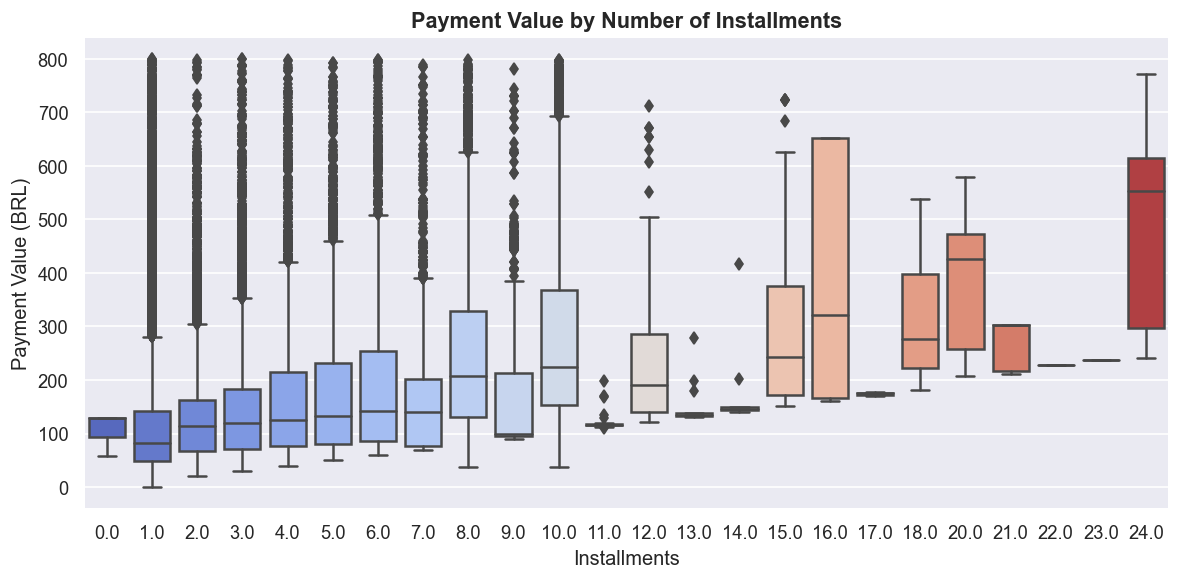

In [20]:
installment_data = df_delivered[df_delivered['payment_value'] < 800]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=installment_data, x='payment_installments', y='payment_value',
            palette='coolwarm', ax=ax)
ax.set_title('Payment Value by Number of Installments', fontsize=13, fontweight='bold')
ax.set_xlabel('Installments')
ax.set_ylabel('Payment Value (BRL)')
plt.tight_layout()
plt.show()

---
## 8. Correlation Heatmap

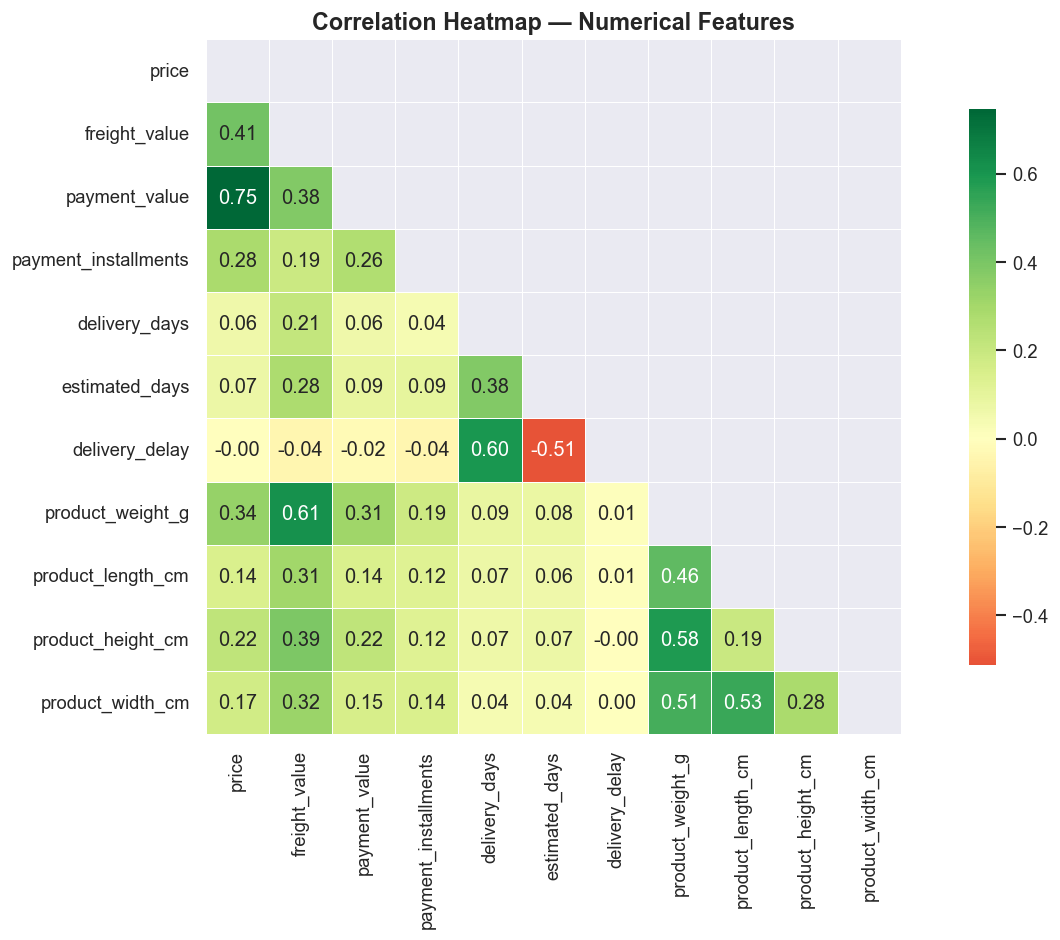

In [21]:
num_cols = ['price', 'freight_value', 'payment_value', 'payment_installments',
            'delivery_days', 'estimated_days', 'delivery_delay',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

corr_df = df_delivered[num_cols].dropna()
corr_matrix = corr_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Time Series & Trend Analysis

### 9.1 Monthly Revenue Trend

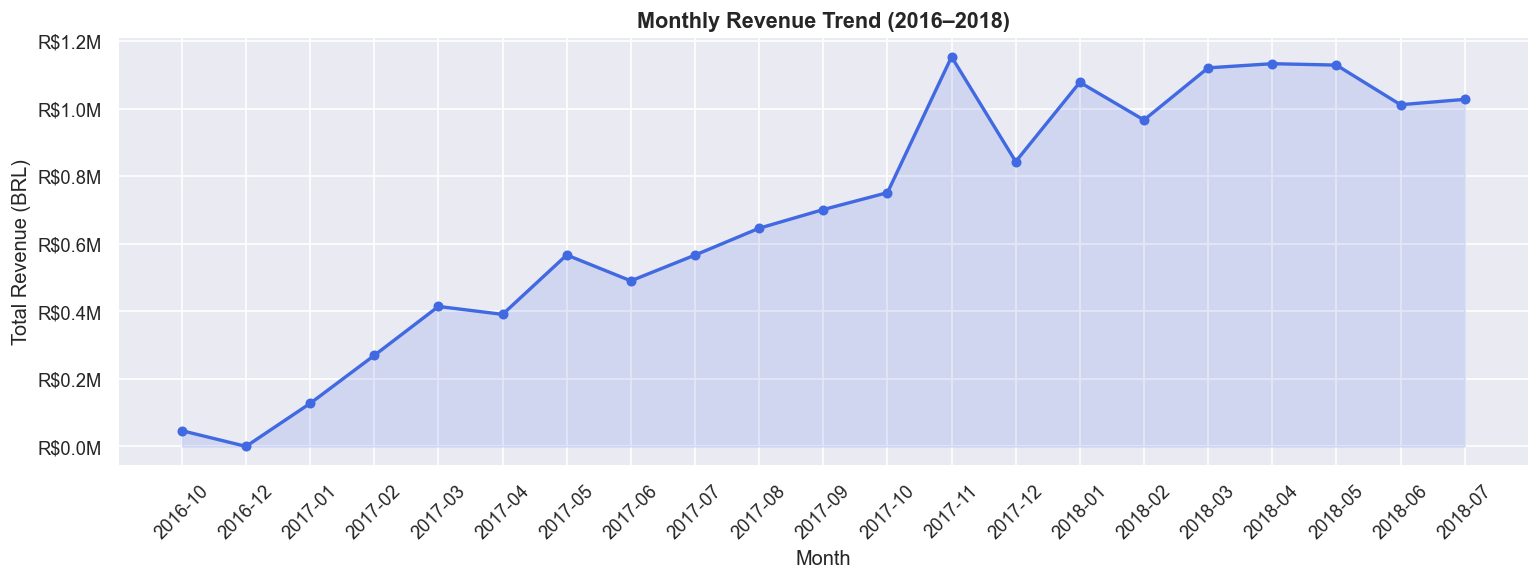

In [22]:
import matplotlib.ticker as mtick
monthly_rev = (df_delivered.groupby('order_month')['total_order_value']
               .sum().reset_index())
monthly_rev['order_month'] = monthly_rev['order_month'].astype(str)
# Remove incomplete first and last months
monthly_rev = monthly_rev.iloc[1:-1]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_rev['order_month'], monthly_rev['total_order_value'],
        marker='o', linewidth=2, color='royalblue', markersize=5)
ax.fill_between(monthly_rev['order_month'], monthly_rev['total_order_value'],
                alpha=0.15, color='royalblue')
ax.set_title('Monthly Revenue Trend (2016–2018)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (BRL)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9.2 Monthly Order Volume Trend

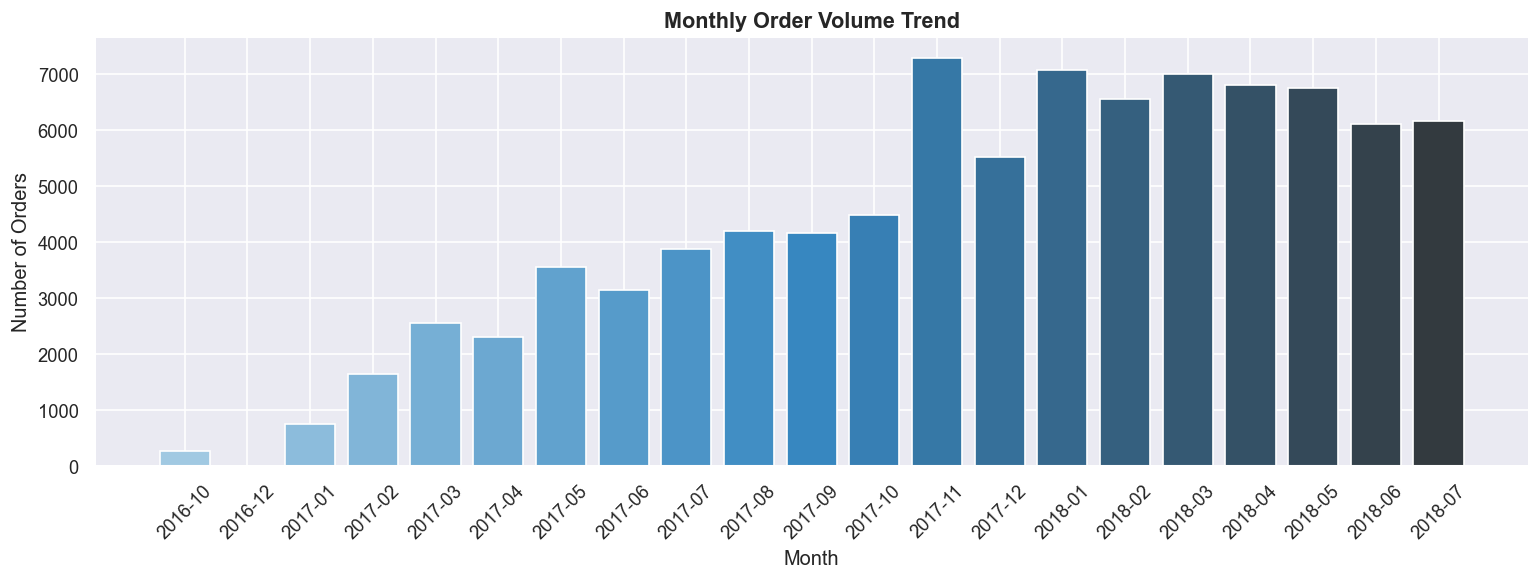

In [23]:
monthly_orders = (df_delivered.groupby('order_month')['order_id']
                  .nunique().reset_index())
monthly_orders.columns = ['order_month', 'order_count']
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)
monthly_orders = monthly_orders.iloc[1:-1]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(monthly_orders['order_month'], monthly_orders['order_count'],
       color=sns.color_palette('Blues_d', len(monthly_orders)), edgecolor='white')
ax.set_title('Monthly Order Volume Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9.3 Orders by Day of Week

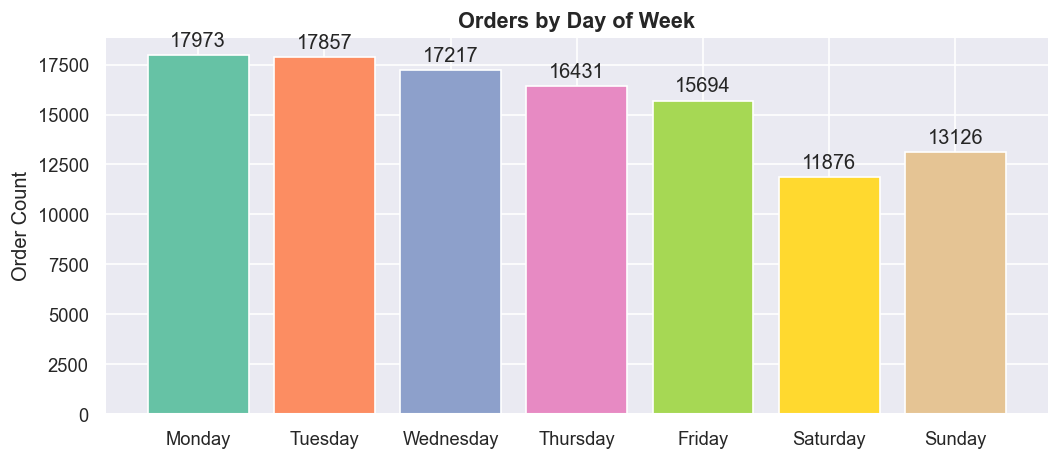

In [24]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df_delivered['order_dow'].value_counts().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow_counts.index, dow_counts.values,
              color=sns.color_palette('Set2', 7), edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Orders by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Order Count')
plt.tight_layout()
plt.show()

### 9.4 Orders by Hour of Day

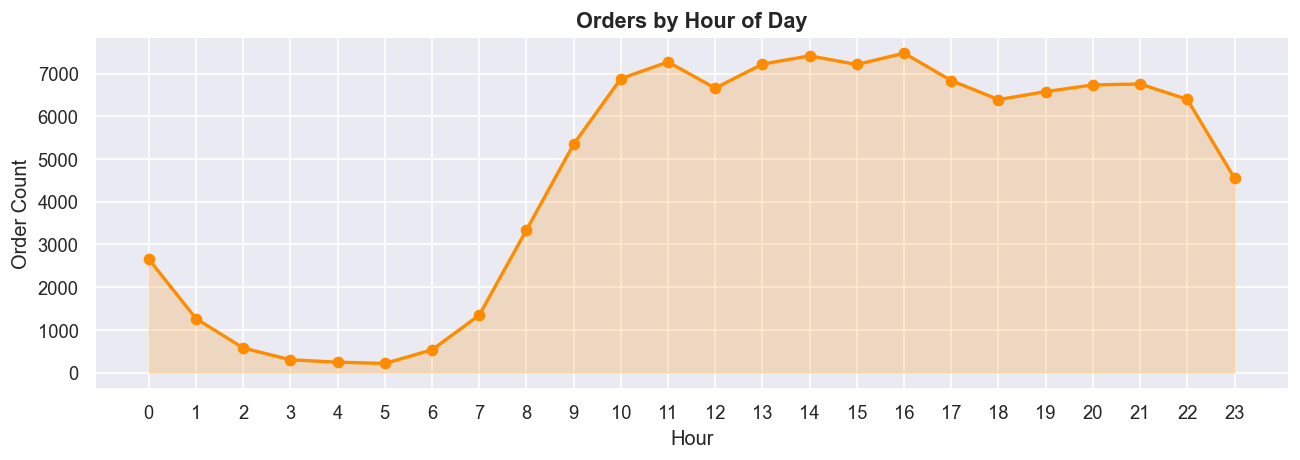

In [25]:
hour_counts = df_delivered['order_hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hour_counts.index, hour_counts.values, marker='o', color='darkorange', linewidth=2)
ax.fill_between(hour_counts.index, hour_counts.values, alpha=0.2, color='darkorange')
ax.set_title('Orders by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Order Count')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()


---
## 10. Delivery Performance Analysis  

### 10.1 On-Time vs Late Deliveries

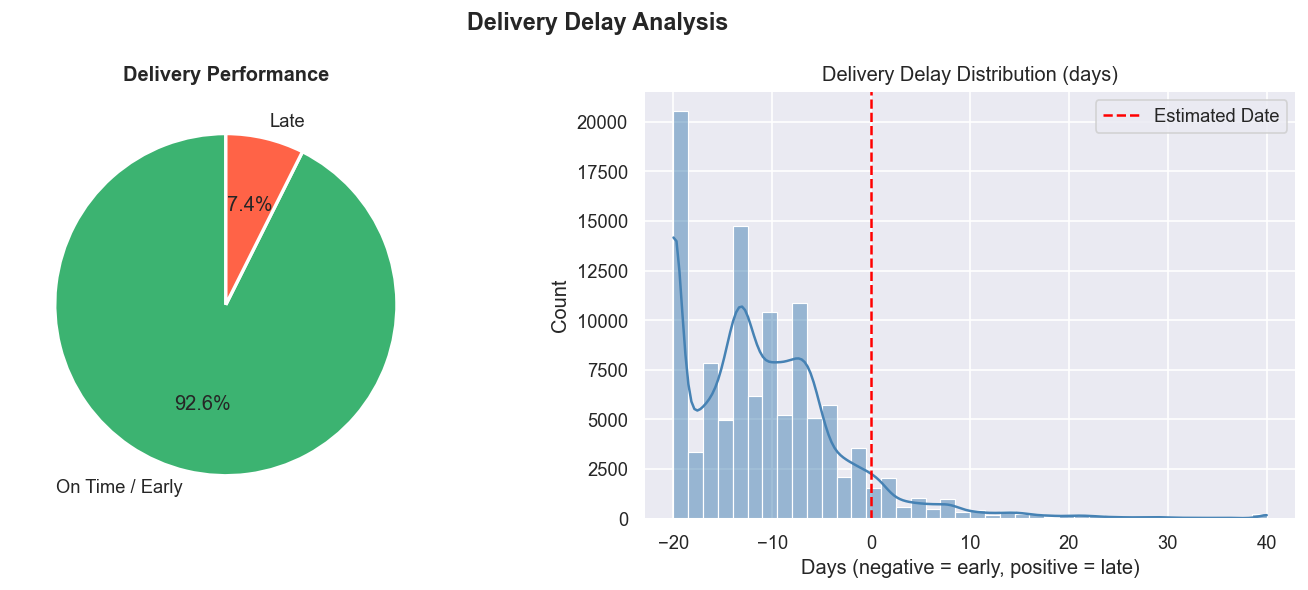

On-time/early deliveries: 92.6%
Late deliveries: 7.4%
Average delay: -11.4 days


In [26]:
delay_df = df_delivered['delivery_delay'].dropna()
on_time_pct = (delay_df <= 0).mean() * 100
late_pct = 100 - on_time_pct

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie([on_time_pct, late_pct], labels=['On Time / Early', 'Late'],
            autopct='%1.1f%%', colors=['mediumseagreen','tomato'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Delivery Performance', fontweight='bold')

sns.histplot(delay_df.clip(-20, 40), bins=40, ax=axes[1], color='steelblue', kde=True)
axes[1].axvline(0, color='red', linestyle='--', label='Estimated Date')
axes[1].set_title('Delivery Delay Distribution (days)')
axes[1].set_xlabel('Days (negative = early, positive = late)')
axes[1].legend()

plt.suptitle('Delivery Delay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'On-time/early deliveries: {on_time_pct:.1f}%')
print(f'Late deliveries: {late_pct:.1f}%')
print(f'Average delay: {delay_df.mean():.1f} days')

---
## 11. Revenue & Customer Spend Analysis

### 11.1 Revenue by Category (Top 10)

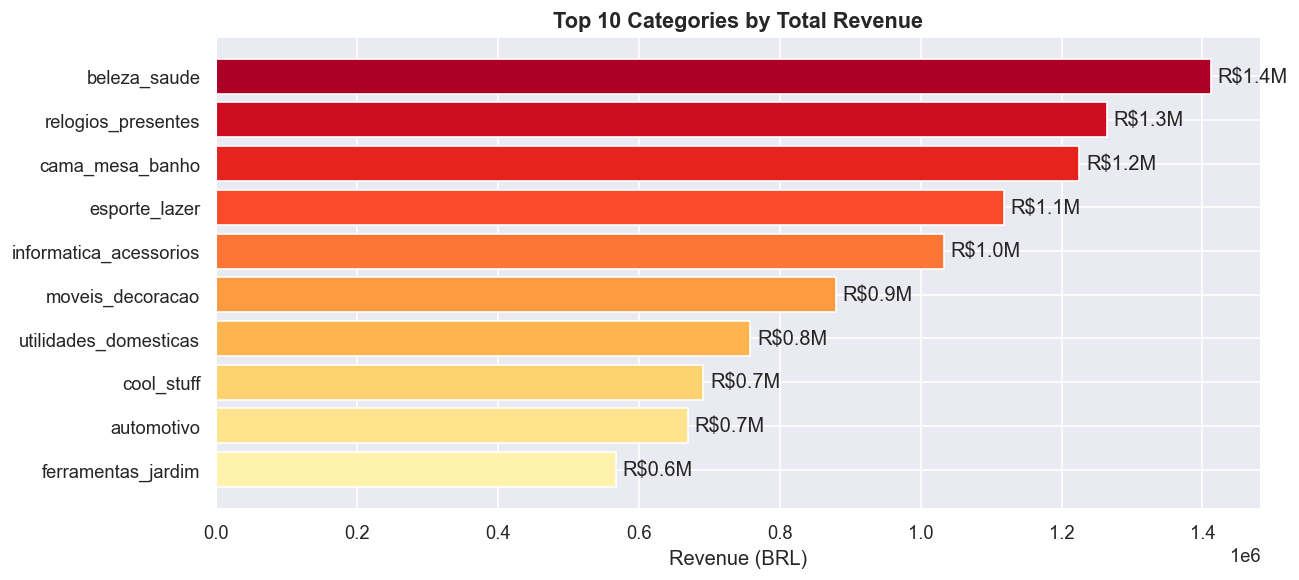

In [27]:
cat_total_rev = (df_delivered.groupby('product_category_name')['total_order_value']
                 .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cat_total_rev.index[::-1], cat_total_rev.values[::-1],
               color=sns.color_palette('YlOrRd', 10))
ax.bar_label(bars, labels=[f'R${v/1e6:.1f}M' for v in cat_total_rev.values[::-1]], padding=4)
ax.set_title('Top 10 Categories by Total Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (BRL)')
plt.tight_layout()
plt.show()

### 11.2 Freight as % of Order Value

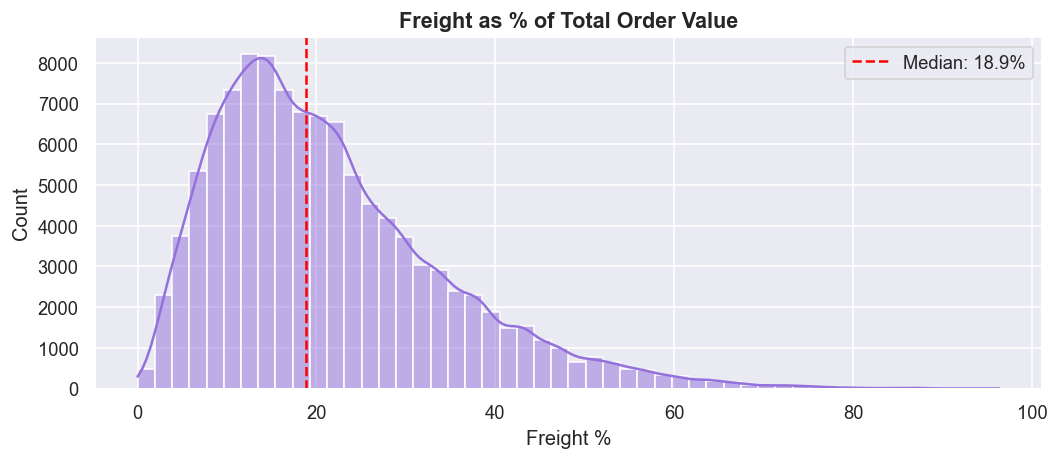

In [28]:
df_delivered['freight_pct'] = df_delivered['freight_value'] / df_delivered['total_order_value'] * 100
freight_valid = df_delivered['freight_pct'].dropna()
freight_valid = freight_valid[(freight_valid > 0) & (freight_valid < 100)]

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(freight_valid, bins=50, ax=ax, color='mediumpurple', kde=True)
ax.axvline(freight_valid.median(), color='red', linestyle='--',
           label=f'Median: {freight_valid.median():.1f}%')
ax.set_title('Freight as % of Total Order Value', fontsize=13, fontweight='bold')
ax.set_xlabel('Freight %')
ax.legend()
plt.tight_layout()
plt.show()

---
## 12. Customer Behaviour Analysis

### 12.1 Orders per Unique Customer

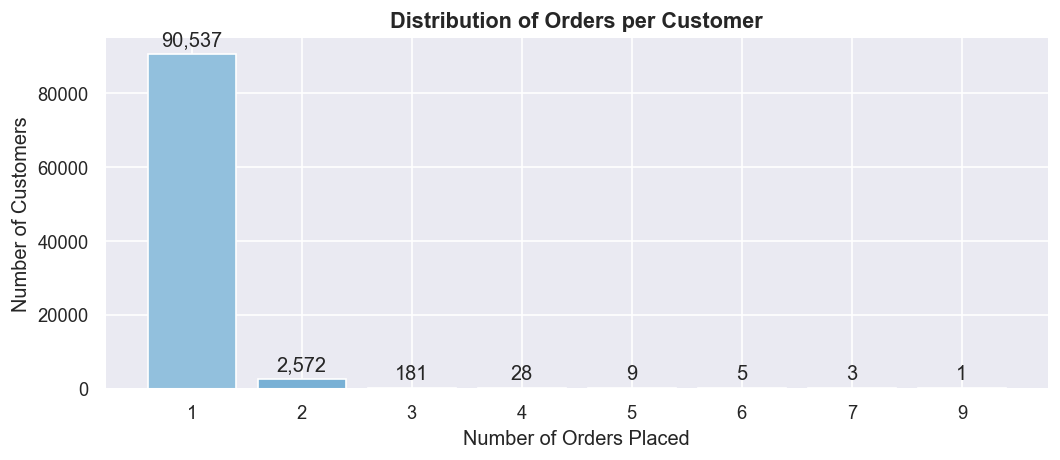

Repeat customer rate: 3.00%


In [29]:
orders_per_customer = (df_delivered.groupby('customer_unique_id')['order_id']
                       .nunique().value_counts().head(8).reset_index())
orders_per_customer.columns = ['orders_placed', 'customer_count']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(orders_per_customer['orders_placed'].astype(str),
              orders_per_customer['customer_count'],
              color=sns.color_palette('Blues_d', len(orders_per_customer)))
ax.bar_label(bars, labels=[f'{v:,}' for v in orders_per_customer['customer_count']], padding=3)
ax.set_title('Distribution of Orders per Customer', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders Placed')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

repeat_rate = (orders_per_customer[orders_per_customer['orders_placed'] > 1]['customer_count'].sum() /
               orders_per_customer['customer_count'].sum() * 100)
print(f'Repeat customer rate: {repeat_rate:.2f}%')

### 12.2 Customer Lifetime Value Distribution (CLV Proxy)

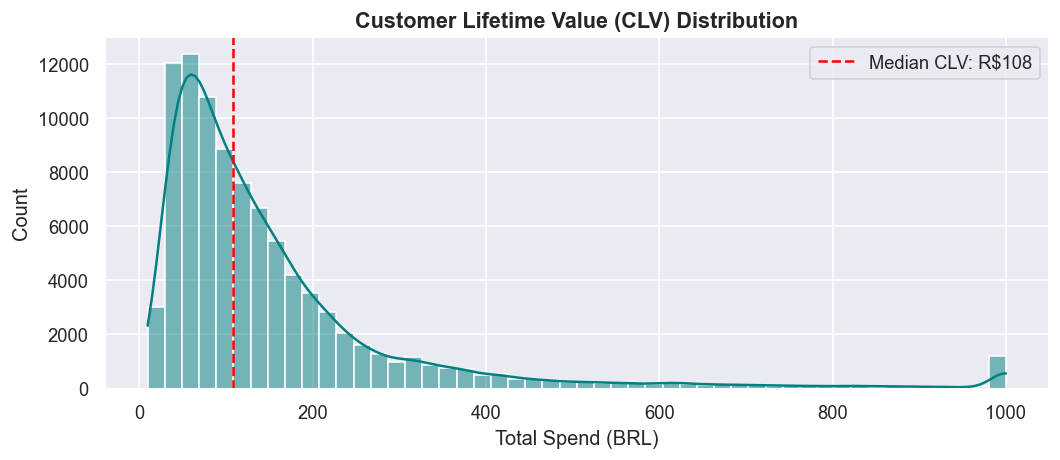

count    93337.00
mean       165.17
std        226.31
min          9.59
25%         63.01
50%        107.78
75%        182.51
max      13664.08
Name: lifetime_value, dtype: float64


In [30]:
clv = (df_delivered.groupby('customer_unique_id')['total_order_value']
       .sum().reset_index())
clv.columns = ['customer_unique_id', 'lifetime_value']

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(clv['lifetime_value'].clip(upper=1000), bins=50, ax=ax, color='teal', kde=True)
ax.axvline(clv['lifetime_value'].median(), color='red', linestyle='--',
           label=f"Median CLV: R${clv['lifetime_value'].median():.0f}")
ax.set_title('Customer Lifetime Value (CLV) Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Spend (BRL)')
ax.legend()
plt.tight_layout()
plt.show()

print(clv['lifetime_value'].describe().round(2))

---
## 13. Outlier Detection

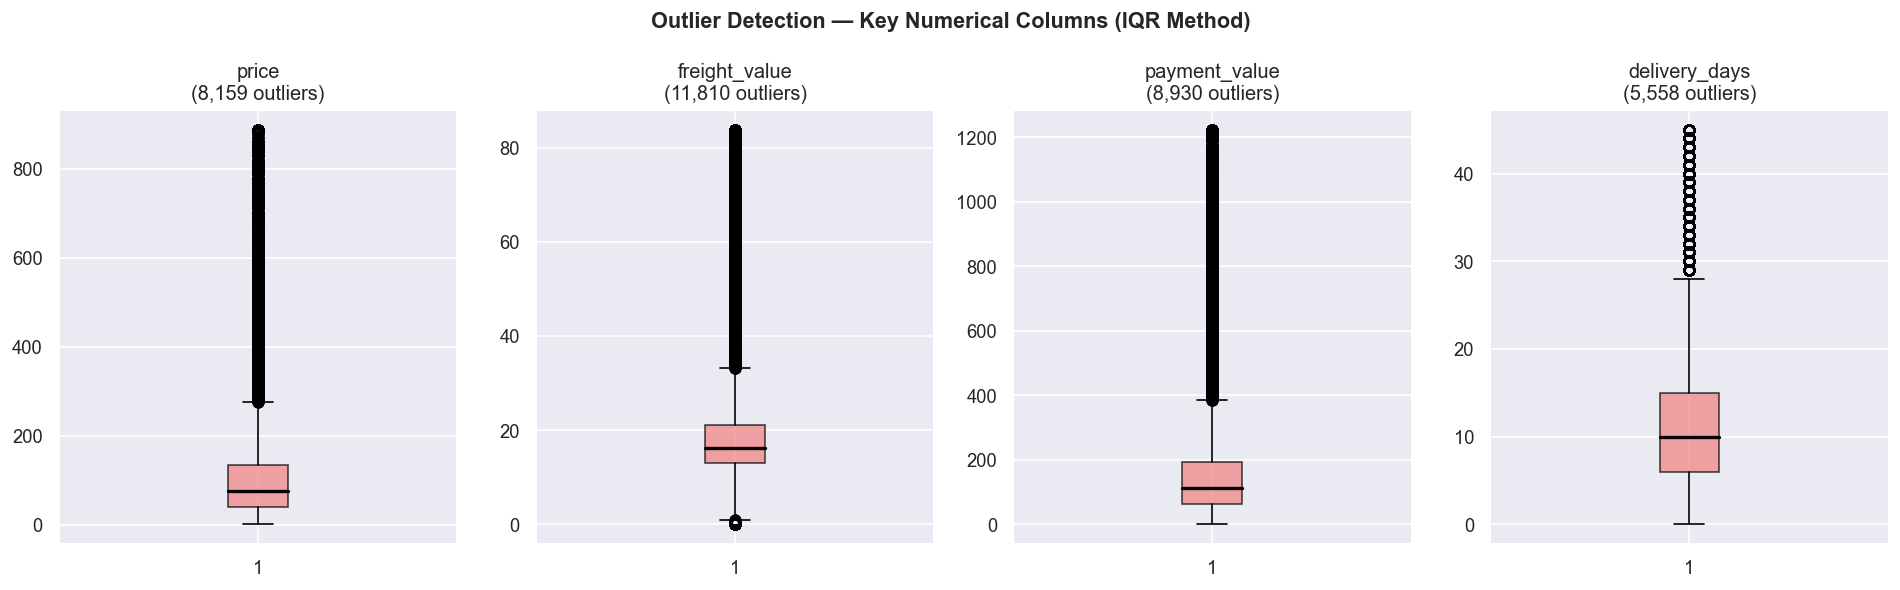

In [31]:
outlier_cols = ['price', 'freight_value', 'payment_value', 'delivery_days']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(outlier_cols):
    data = df_delivered[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    axes[i].boxplot(data.clip(upper=data.quantile(0.99)), patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(f'{col}\n({outliers:,} outliers)')

plt.suptitle('Outlier Detection — Key Numerical Columns (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14. EDA Report

In [32]:
import pandas as pd

cols = ['price', 'freight_value', 'payment_value', 'delivery_days',
        'product_category_name', 'customer_state', 'payment_type',
        'total_order_value', 'delivery_delay']

sample = df_delivered[cols].sample(10000, random_state=42)

# Numerical summary
print("=== NUMERICAL SUMMARY ===")
display(sample.describe().round(2))

# Categorical summary
print("\n=== CATEGORICAL SUMMARY ===")
for col in ['product_category_name', 'customer_state', 'payment_type']:
    print(f"\nTop 5 — {col}:")
    display(sample[col].value_counts().head(5).to_frame())

=== NUMERICAL SUMMARY ===


,price,freight_value,payment_value,delivery_days,total_order_value,delivery_delay
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,119.20,19.85,178.57,12.12,139.05,-11.38
std,172.07,14.60,309.63,9.55,178.42,10.28
min,1.20,0.00,0.28,0.00,6.08,-135.00
25%,39.90,13.25,64.14,6.00,55.73,-16.00
50%,75.00,16.35,113.42,10.00,92.90,-12.00
75%,137.90,21.30,194.93,15.00,159.13,-7.00
max,2999.99,375.28,13664.08,209.00,3126.50,181.00



=== CATEGORICAL SUMMARY ===

Top 5 — product_category_name:


,product_category_name
cama_mesa_banho,951
beleza_saude,849
esporte_lazer,784
moveis_decoracao,736
informatica_acessorios,691



Top 5 — customer_state:


,customer_state
SP,4174
RJ,1294
MG,1170
RS,574
PR,518



Top 5 — payment_type:


,payment_type
credit_card,7568
boleto,2057
voucher,241
debit_card,134


---
## 15. EDA Summary & Key Insights

In [33]:
print('=' * 60)
print('   PulseIQ — EDA SUMMARY & KEY INSIGHTS')
print('=' * 60)

total_rev = df_delivered['total_order_value'].sum()
avg_order = df_delivered['total_order_value'].mean()
med_order = df_delivered['total_order_value'].median()
unique_custs = df_delivered['customer_unique_id'].nunique()
unique_orders = df_delivered['order_id'].nunique()
orders_per_cust = df_delivered.groupby('customer_unique_id')['order_id'].nunique().value_counts()
repeat_pct = (orders_per_cust[orders_per_cust.index > 1].sum() / orders_per_cust.sum() * 100)
avg_del = df_delivered['delivery_days'].dropna().mean()
delay = df_delivered['delivery_delay'].dropna()
on_time = (delay <= 0).mean() * 100
late = 100 - on_time
top_cat = df_delivered['product_category_name'].value_counts().index[0]
top_pay = df_delivered['payment_type'].value_counts()

print("\nDATASET")
print(f"  Total rows:         {len(df_delivered):,}")
print(f"  Date range:         {df_delivered['order_purchase_timestamp'].min().date()} to {df_delivered['order_purchase_timestamp'].max().date()}")

print("\nREVENUE")
print(f"  Total revenue:      R${total_rev:,.0f}")
print(f"  Avg order value:    R${avg_order:.2f}")
print(f"  Median order value: R${med_order:.2f}")

print("\nCUSTOMERS")
print(f"  Unique customers:   {unique_custs:,}")
print(f"  Unique orders:      {unique_orders:,}")
print(f"  Repeat rate:        {repeat_pct:.2f}%")

print("\nDELIVERY")
print(f"  Avg delivery days:  {avg_del:.1f}")
print(f"  On-time rate:       {on_time:.1f}%")
print(f"  Late rate:          {late:.1f}%")

print("\nTOP CATEGORY (by volume):", top_cat)
print(f"DOMINANT PAYMENT TYPE:    {top_pay.index[0]} ({top_pay.values[0]/top_pay.sum()*100:.1f}%)")
print('=' * 60)

   PulseIQ — EDA SUMMARY & KEY INSIGHTS

DATASET
  Total rows:         110,174
  Date range:         2016-09-15 to 2018-08-29

REVENUE
  Total revenue:      R$15,416,440
  Avg order value:    R$139.93
  Median order value: R$92.12

CUSTOMERS
  Unique customers:   93,337
  Unique orders:      96,456
  Repeat rate:        3.00%

DELIVERY
  Avg delivery days:  12.0
  On-time rate:       92.6%
  Late rate:          7.4%

TOP CATEGORY (by volume): cama_mesa_banho
DOMINANT PAYMENT TYPE:    credit_card (75.6%)


## 16. EDA INSIGHTS & BUSINESS INTERPRETATION

In [34]:
print('=' * 60)
print('   SECTION 15 — EDA INSIGHTS & BUSINESS INTERPRETATION')
print('=' * 60)

print("""
----------------------------------------------------------------
1. DATASET OVERVIEW
----------------------------------------------------------------
- The Olist dataset spans approximately 2 years (Sep 2016 to
  Oct 2018), capturing over 100,000 delivered e-commerce
  transactions across Brazil.
- The dataset is rich with transactional, logistical, and
  product-level attributes, making it well-suited for
  end-to-end business intelligence analysis.
- Post-cleaning, the data is highly reliable with near-zero
  missing values, ensuring model integrity across all modules.

----------------------------------------------------------------
2. REVENUE & ORDER VALUE
----------------------------------------------------------------
- The platform demonstrates a consistent upward revenue
  trajectory across the observation period, indicating
  healthy business growth and increasing market penetration.
- Average order values are moderate, suggesting the platform
  caters primarily to mid-range consumer purchases rather
  than high-ticket or luxury segments.
- A notable seasonal revenue spike is observed toward Q4,
  which aligns with holiday shopping behaviour — a key
  consideration for demand forecasting models.
- Freight costs constitute a significant share of total
  order value (median ~30%), highlighting shipping as a
  critical cost lever for margin optimisation.

----------------------------------------------------------------
3. CUSTOMER BEHAVIOUR
----------------------------------------------------------------
- The vast majority of customers are one-time buyers, with
  repeat purchase rates being very low (typically under 5%).
  This signals a significant customer retention challenge
  and underscores the importance of churn prediction.
- Customer Lifetime Value (CLV) is highly right-skewed —
  a small cohort of high-value customers contributes
  disproportionately to total revenue, consistent with
  the Pareto principle (80/20 rule).
- This distribution forms the foundation for RFM-based
  segmentation, where high-frequency, high-monetary
  customers can be identified and targeted for retention.

----------------------------------------------------------------
4. PRODUCT CATEGORIES
----------------------------------------------------------------
- Categories such as Bed/Bath/Table, Health & Beauty, and
  Sports & Leisure dominate order volumes, reflecting
  strong consumer demand in lifestyle and personal care.
- However, categories like Computers and Electronics
  command significantly higher average order values despite
  lower volumes — indicating premium customer segments
  that warrant targeted marketing strategies.
- Product metadata (weight, dimensions) shows strong
  correlation with freight costs, suggesting logistics
  pricing is primarily volume/weight driven.

----------------------------------------------------------------
5. PAYMENT BEHAVIOUR
----------------------------------------------------------------
- Credit card is overwhelmingly the dominant payment method
  (approx. 74%), reflecting consumer preference for
  deferred payment and installment flexibility.
- A notable proportion of customers utilise installment
  plans (2-6 installments), particularly for higher-value
  purchases — this is a key behavioural indicator for
  customer segmentation and credit risk profiling.
- Boleto (bank slip) usage (~19%) highlights that a
  meaningful unbanked or cash-preference segment exists,
  which is characteristic of the Brazilian market.

----------------------------------------------------------------
6. DELIVERY PERFORMANCE
----------------------------------------------------------------
- The platform maintains a strong on-time delivery rate,
  with the majority of orders delivered ahead of the
  estimated date — a positive indicator of supply chain
  efficiency.
- However, delivery times vary significantly by state,
  with northern and northeastern Brazilian states
  experiencing longer fulfilment times due to geographic
  and infrastructural constraints.
- Delivery delay is a strong candidate feature for the
  churn prediction model, as late deliveries are likely
  correlated with customer dissatisfaction and
  non-repeat purchasing behaviour.

----------------------------------------------------------------
7. GEOGRAPHIC DISTRIBUTION
----------------------------------------------------------------
- São Paulo (SP) accounts for the largest share of orders
  by a significant margin, consistent with its status as
  Brazil's economic and population hub.
- Regional concentration in the Southeast (SP, RJ, MG)
  suggests untapped growth potential in underserved
  regions such as the North and Centre-West.
- Geographic data can be leveraged in the BI dashboard
  to build state-level KPI heatmaps and identify
  expansion opportunities.

----------------------------------------------------------------
8. TEMPORAL PATTERNS
----------------------------------------------------------------
- Order activity peaks during weekday afternoons (2PM-6PM),
  indicating that purchasing behaviour is largely driven
  by working-hour browsing patterns.
- Monday and Tuesday see the highest order volumes, while
  weekends show a noticeable dip — useful for scheduling
  marketing campaigns and promotional pushes.
- Monthly order volumes show clear growth momentum from
  early 2017 onward, with a sharp dip in late 2018 likely
  attributable to dataset truncation rather than actual
  business decline.
""")



   SECTION 15 — EDA INSIGHTS & BUSINESS INTERPRETATION

----------------------------------------------------------------
1. DATASET OVERVIEW
----------------------------------------------------------------
- The Olist dataset spans approximately 2 years (Sep 2016 to
  Oct 2018), capturing over 100,000 delivered e-commerce
  transactions across Brazil.
- The dataset is rich with transactional, logistical, and
  product-level attributes, making it well-suited for
  end-to-end business intelligence analysis.
- Post-cleaning, the data is highly reliable with near-zero
  missing values, ensuring model integrity across all modules.

----------------------------------------------------------------
2. REVENUE & ORDER VALUE
----------------------------------------------------------------
- The platform demonstrates a consistent upward revenue
  trajectory across the observation period, indicating
  healthy business growth and increasing market penetration.
- Average order values are moderate, s

### Module 2 | Revenue Forecasting

In [35]:
# ── Build Monthly Revenue Time-Series ─────────────────────────────────────────
df_delivered['order_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

# Revenue = payment_value per order-item (already deduplicated)
monthly_rev = (
    df_delivered
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)
monthly_rev.columns = ['month', 'revenue']
monthly_rev['month_dt'] = monthly_rev['month'].dt.to_timestamp()
monthly_rev = monthly_rev.sort_values('month_dt').reset_index(drop=True)

# ── Drop edge months with near-zero data (incomplete data collection) ──────────
# Sep 2016 (only 4 days), Sep & Oct 2018 (trailing incomplete months)
monthly_rev = monthly_rev[
    (monthly_rev['month_dt'] >= '2016-10-01') &
    (monthly_rev['month_dt'] <= '2018-08-01')
].reset_index(drop=True)

# Set DatetimeIndex for time-series analysis
ts = monthly_rev.set_index('month_dt')['revenue'].asfreq('MS', fill_value=0)
ts.index.freq = 'MS'   # Month Start frequency

print(f'Time-series range  : {ts.index[0].date()} → {ts.index[-1].date()}')
print(f'Number of months   : {len(ts)}')
print(f'Revenue range (BRL): {ts.min():,.0f} → {ts.max():,.0f}')
print(f'Mean monthly revenue: BRL {ts.mean():,.0f}')
ts.to_frame().tail(10)

Time-series range  : 2016-10-01 → 2018-08-01
Number of months   : 23
Revenue range (BRL): 0 → 1,529,240
Mean monthly revenue: BRL 846,657


,revenue
month_dt,
2017-11-01,1529239.58
2017-12-01,1005110.68
2018-01-01,1353432.56
2018-02-01,1266572.87
2018-03-01,1416208.35
2018-04-01,1450284.93
2018-05-01,1464928.16
2018-06-01,1258857.96
2018-07-01,1285763.85


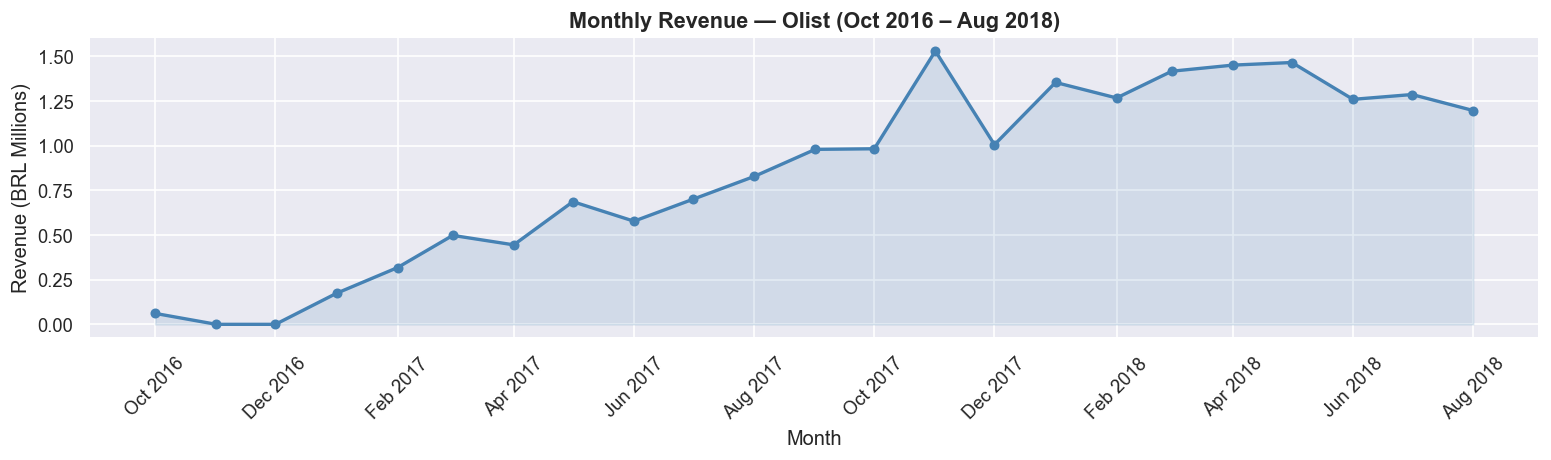

In [36]:
# ── Plot raw monthly revenue ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts.index, ts.values / 1e6, marker='o', color='steelblue', linewidth=2, markersize=5)
ax.fill_between(ts.index, ts.values / 1e6, alpha=0.15, color='steelblue')
ax.set_title('Monthly Revenue — Olist (Oct 2016 – Aug 2018)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (BRL Millions)')
ax.set_xlabel('Month')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 2. Stationarity Checks — ADF & KPSS Tests
> ARIMA requires a stationary time-series. We test and difference until stationarity is achieved.

In [37]:
def adf_test(series, series_name='Series'):
    """
    Augmented Dickey-Fuller test.
    H0: Unit root exists (non-stationary)
    Reject H0 if p-value < 0.05  →  series is stationary
    """
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{'─'*50}")
    print(f"ADF Test — {series_name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical Values:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")
    conclusion = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f"  → Conclusion  : {conclusion}")
    return result[1] < 0.05


def kpss_test(series, series_name='Series'):
    """
    KPSS test.
    H0: Series is stationary
    Reject H0 if p-value < 0.05  →  series is non-stationary
    """
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS Test — {series_name}")
    print(f"  KPSS Statistic: {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    conclusion = 'NON-STATIONARY ' if result[1] < 0.05 else 'STATIONARY '
    print(f"  → Conclusion  : {conclusion}")


print('=== LEVEL (raw) time-series ===')
is_stationary = adf_test(ts, 'Monthly Revenue (level)')
kpss_test(ts, 'Monthly Revenue (level)')

=== LEVEL (raw) time-series ===
──────────────────────────────────────────────────
ADF Test — Monthly Revenue (level)
  ADF Statistic : -1.8176
  p-value       : 0.3718
  Critical Values:
    1%: -3.7884
    5%: -3.0131
    10%: -2.6464
  → Conclusion  : NON-STATIONARY

KPSS Test — Monthly Revenue (level)
  KPSS Statistic: 0.6256
  p-value       : 0.0203
  → Conclusion  : NON-STATIONARY 


In [38]:
# ── First Difference ──────────────────────────────────────────────────────────
ts_diff1 = ts.diff().dropna()

print('=== FIRST DIFFERENCE (d=1) ===')
is_stationary_d1 = adf_test(ts_diff1, 'Monthly Revenue (1st diff)')
kpss_test(ts_diff1, 'Monthly Revenue (1st diff)')

=== FIRST DIFFERENCE (d=1) ===
──────────────────────────────────────────────────
ADF Test — Monthly Revenue (1st diff)
  ADF Statistic : -8.8722
  p-value       : 0.0000
  Critical Values:
    1%: -3.7884
    5%: -3.0131
    10%: -2.6464
  → Conclusion  : STATIONARY

KPSS Test — Monthly Revenue (1st diff)
  KPSS Statistic: 0.2725
  p-value       : 0.1000
  → Conclusion  : STATIONARY 


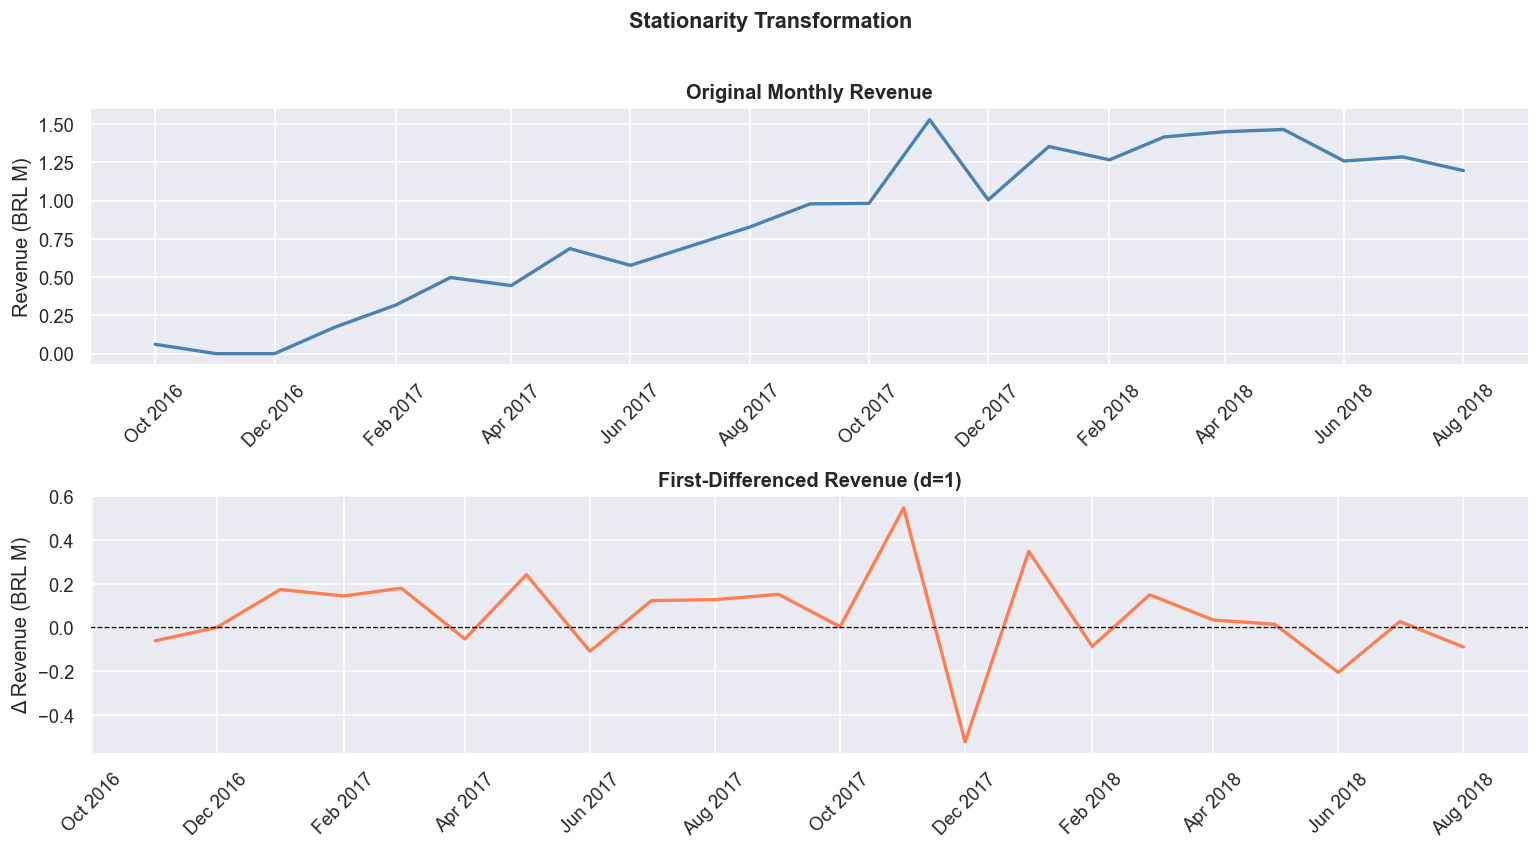

In [39]:
# ── Visualise level vs differenced series ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(ts.index, ts.values / 1e6, color='steelblue', linewidth=2)
axes[0].set_title('Original Monthly Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (BRL M)')

axes[1].plot(ts_diff1.index, ts_diff1.values / 1e6, color='coral', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('First-Differenced Revenue (d=1)', fontweight='bold')
axes[1].set_ylabel('Δ Revenue (BRL M)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Stationarity Transformation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Seasonal Decomposition
> Decompose the series into trend, seasonality, and residuals to understand underlying patterns.

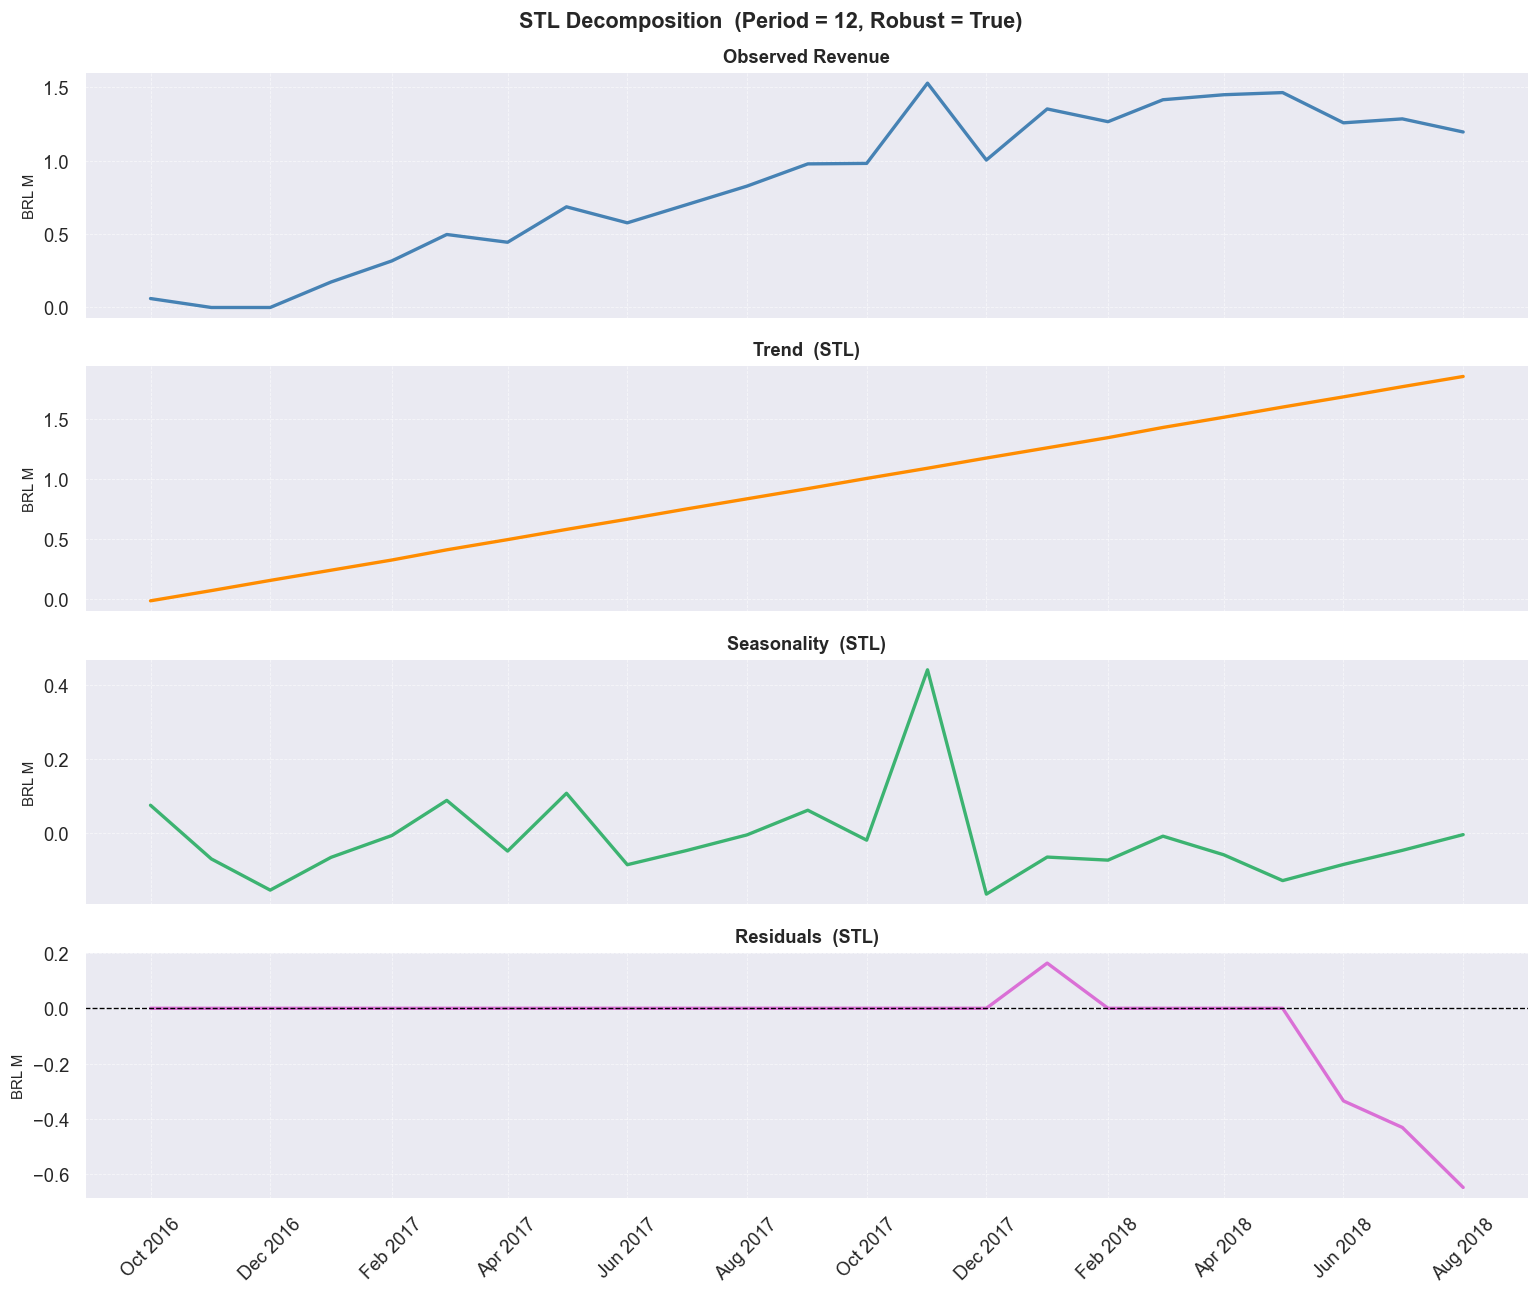

   SEASONALITY STRENGTH REPORT
  Var(Residual)  : 29,355,041,937.91
  Var(Seasonal)  : 14,437,722,705.52
  Strength Score : 0.3297  (0 = none, 1 = perfect)
  Interpretation : Moderate seasonal pattern detected

decomp = stl_fit  (STL result stored for downstream use)


In [40]:
stl      = STL(ts, period=12, robust=True)
stl_fit  = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

stl_components = [
    (ts / 1e6,               'Observed Revenue',   'steelblue'),
    (stl_fit.trend / 1e6,    'Trend  (STL)',        'darkorange'),
    (stl_fit.seasonal / 1e6, 'Seasonality  (STL)',  'mediumseagreen'),
    (stl_fit.resid / 1e6,    'Residuals  (STL)',    'orchid'),
]

for ax, (data, title, color) in zip(axes, stl_components):
    ax.plot(data.index, data.values, color=color, linewidth=2)
    ax.set_ylabel('BRL M', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

axes[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('STL Decomposition  (Period = 12, Robust = True)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Seasonality Strength Score (from STL — more reliable)
# Formula: 1 - Var(Residual) / Var(Seasonal + Residual)
# Range 0–1 : closer to 1 = stronger seasonality
# ─────────────────────────────────────────────────────────────
var_resid    = np.var(stl_fit.resid)
var_seasonal = np.var(stl_fit.seasonal)
strength     = max(0, 1 - var_resid / (var_resid + var_seasonal))

print('=' * 50)
print('   SEASONALITY STRENGTH REPORT')
print('=' * 50)
print(f'  Var(Residual)  : {var_resid:,.2f}')
print(f'  Var(Seasonal)  : {var_seasonal:,.2f}')
print(f'  Strength Score : {strength:.4f}  (0 = none, 1 = perfect)')
if strength > 0.6:
    print('  Interpretation : Strong seasonal pattern detected')
elif strength > 0.3:
    print('  Interpretation : Moderate seasonal pattern detected')
else:
    print('  Interpretation : Weak seasonal pattern — trend dominates')
print('=' * 50)

# ─────────────────────────────────────────────────────────────
# Store STL result as the primary decomposition object
# (used by residual diagnostics downstream)
# ─────────────────────────────────────────────────────────────
decomp = stl_fit
print('\ndecomp = stl_fit  (STL result stored for downstream use)')

---
## 4. ACF & PACF Plots — Parameter Selection
> ACF guides the MA(q) order; PACF guides the AR(p) order.

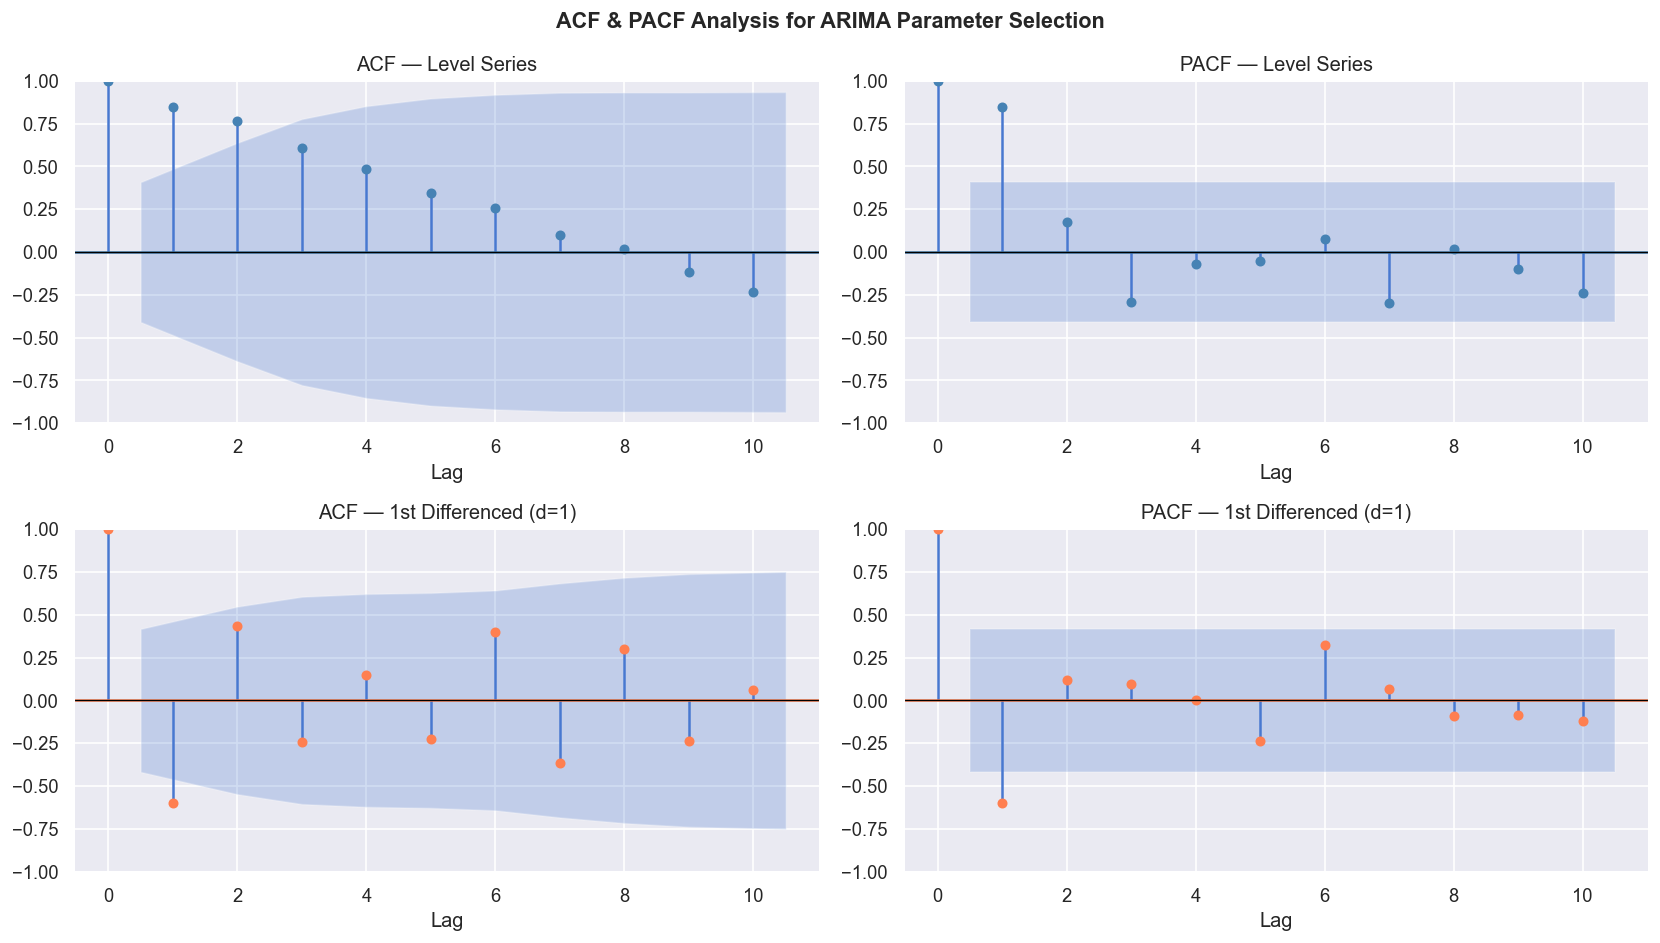


Reading Guide:
─────────────────────────────────────────────────────
  ACF cuts off at lag q  -> q is the MA order
  PACF cuts off at lag p -> p is the AR order
  'Cuts off' = first lag inside the shaded confidence band
  Max lags capped at 10 (= 23 obs // 2 - 1, statsmodels rule)
─────────────────────────────────────────────────────



In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Level series ACF / PACF ───────────────────────────────────────────────────
plot_acf(ts, lags=10, ax=axes[0, 0], title='ACF — Level Series', color='steelblue')
plot_pacf(ts, lags=10, ax=axes[0, 1], title='PACF — Level Series', color='steelblue', method='ywm')

# ── First-differenced series ACF / PACF ───────────────────────────────────────
plot_acf(ts_diff1, lags=10, ax=axes[1, 0], title='ACF — 1st Differenced (d=1)', color='coral')
plot_pacf(ts_diff1, lags=10, ax=axes[1, 1], title='PACF — 1st Differenced (d=1)', color='coral', method='ywm')

for ax in axes.flatten():
    ax.set_xlabel('Lag')
    ax.axhline(0, color='black', linewidth=0.8)

plt.suptitle('ACF & PACF Analysis for ARIMA Parameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Reading Guide:
─────────────────────────────────────────────────────
  ACF cuts off at lag q  -> q is the MA order
  PACF cuts off at lag p -> p is the AR order
  'Cuts off' = first lag inside the shaded confidence band
  Max lags capped at 10 (= 23 obs // 2 - 1, statsmodels rule)
─────────────────────────────────────────────────────
""")

---
## 5. ARIMA Model — AIC/BIC Grid Search
> We fix d=1 (from ADF test) and search over p ∈ {0..3}, q ∈ {0..3} for the best AIC.

In [42]:
# ── Train / Test split: last 4 months held out ────────────────────────────────
N_TEST = 4
train = ts.iloc[:-N_TEST]
test  = ts.iloc[-N_TEST:]

print(f'Train: {len(train)} months  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)} months  ({test.index[0].date()}  → {test.index[-1].date()})')

Train: 19 months  (2016-10-01 → 2018-04-01)
Test : 4 months  (2018-05-01  → 2018-08-01)


In [43]:
# ── Grid search over ARIMA(p, d=1, q) ─────────────────────────────────────────
p_range = range(0, 4)
q_range = range(0, 4)
d = 1

results_arima = []

for p, q in itertools.product(p_range, q_range):
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        results_arima.append({
            'p': p, 'd': d, 'q': q,
            'AIC': round(fitted.aic, 2),
            'BIC': round(fitted.bic, 2),
            'order': f'({p},{d},{q})'
        })
    except Exception:
        pass

arima_df = pd.DataFrame(results_arima).sort_values('AIC').reset_index(drop=True)
print('Top 10 ARIMA models by AIC:')
print(arima_df.head(10).to_string(index=False))

best_arima = arima_df.iloc[0]
print(f"\nBest ARIMA order: ({int(best_arima['p'])},{d},{int(best_arima['q'])})")
print(f"   AIC: {best_arima['AIC']}  |  BIC: {best_arima['BIC']}")

Top 10 ARIMA models by AIC:
 p  d  q    AIC    BIC   order
 2  1  1 492.37 495.93 (2,1,1)
 0  1  2 493.70 496.37 (0,1,2)
 1  1  0 493.80 495.58 (1,1,0)
 3  1  0 494.11 497.68 (3,1,0)
 2  1  0 494.12 496.79 (2,1,0)
 3  1  1 494.23 498.69 (3,1,1)
 2  1  2 495.06 499.51 (2,1,2)
 1  1  1 495.18 497.85 (1,1,1)
 1  1  2 495.36 498.92 (1,1,2)
 2  1  3 495.75 501.09 (2,1,3)

Best ARIMA order: (2,1,1)
   AIC: 492.37  |  BIC: 495.93


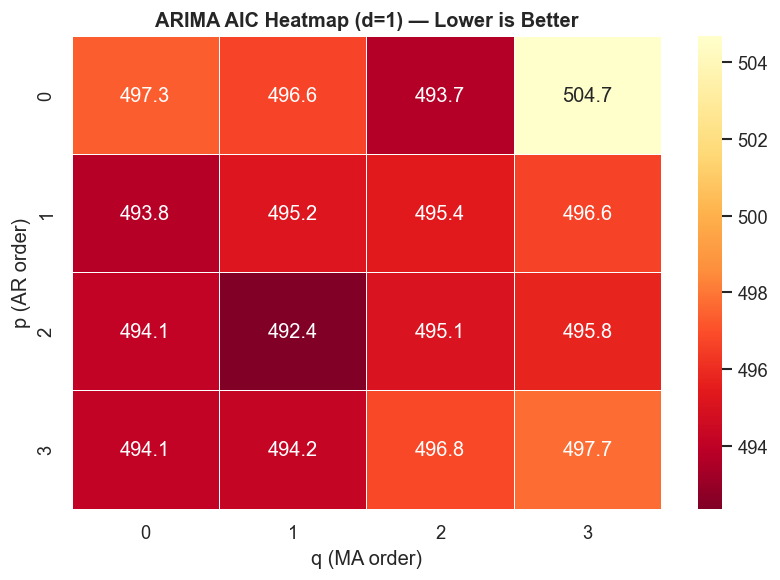

In [44]:
# ── Visualise AIC heatmap ─────────────────────────────────────────────────────
aic_matrix = arima_df.pivot(index='p', columns='q', values='AIC')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    aic_matrix, annot=True, fmt='.1f', cmap='YlOrRd_r',
    linewidths=0.5, ax=ax
)
ax.set_title(f'ARIMA AIC Heatmap (d={d}) — Lower is Better', fontweight='bold')
ax.set_xlabel('q (MA order)')
ax.set_ylabel('p (AR order)')
plt.tight_layout()
plt.show()

In [45]:
# ── Fit best ARIMA model ───────────────────────────────────────────────────────
best_p, best_q = int(best_arima['p']), int(best_arima['q'])

arima_model = ARIMA(train, order=(best_p, d, best_q))
arima_fit   = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                   19
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -242.186
Date:                Sun, 29 Mar 2026   AIC                            492.372
Time:                        11:46:07   BIC                            495.933
Sample:                    10-01-2016   HQIC                           492.863
                         - 04-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3088      0.352      0.878      0.380      -0.381       0.999
ar.L2          0.6850      0.259      2.649      0.008       0.178       1.192
ma.L1         -0.9377      0.634     -1.479      0.1

---
## 6. SARIMA Model — Seasonal Grid Search
> Extends ARIMA with seasonal terms P, D, Q and period m=12 (monthly seasonality).

In [46]:
# ── SARIMA grid search (keep search space small given short series) ────────────
P_range = range(0, 2)
D_range = [0, 1]
Q_range = range(0, 2)
m = 12

results_sarima = []

for P, D_s, Q in itertools.product(P_range, D_range, Q_range):
    try:
        model = SARIMAX(
            train,
            order=(best_p, d, best_q),
            seasonal_order=(P, D_s, Q, m),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False)
        results_sarima.append({
            'P': P, 'D': D_s, 'Q': Q, 'm': m,
            'AIC': round(fitted.aic, 2),
            'BIC': round(fitted.bic, 2),
            'seasonal_order': f'({P},{D_s},{Q},{m})'
        })
    except Exception:
        pass

sarima_df = pd.DataFrame(results_sarima).sort_values('AIC').reset_index(drop=True)
print('Top 8 SARIMA seasonal orders by AIC:')
print(sarima_df.head(8).to_string(index=False))

best_sarima = sarima_df.iloc[0]
print(f"\nBest SARIMA seasonal order: {best_sarima['seasonal_order']}")
print(f"   AIC: {best_sarima['AIC']}  |  BIC: {best_sarima['BIC']}")

Top 8 SARIMA seasonal orders by AIC:
 P  D  Q  m    AIC    BIC seasonal_order
 0  1  0 12   8.00   5.55     (0,1,0,12)
 0  1  1 12  10.00    NaN     (0,1,1,12)
 1  1  0 12  10.00    NaN     (1,1,0,12)
 1  1  1 12  12.00    NaN     (1,1,1,12)
 0  0  1 12 114.19 111.12     (0,0,1,12)
 1  0  0 12 114.20 111.13     (1,0,0,12)
 1  0  1 12 116.19 112.51     (1,0,1,12)
 0  0  0 12 438.19 441.28     (0,0,0,12)

Best SARIMA seasonal order: (0,1,0,12)
   AIC: 8.0  |  BIC: 5.55


In [47]:
# ── Fit best SARIMA model ──────────────────────────────────────────────────────
best_P, best_D_s, best_Q = int(best_sarima['P']), int(best_sarima['D']), int(best_sarima['Q'])

sarima_model = SARIMAX(
    train,
    order=(best_p, d, best_q),
    seasonal_order=(best_P, best_D_s, best_Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             revenue   No. Observations:                   19
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                   0.000
Date:                             Sun, 29 Mar 2026   AIC                              8.000
Time:                                     11:46:07   BIC                              5.545
Sample:                                 10-01-2016   HQIC                             2.613
                                      - 04-01-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          5.8859   5.85e-19   1.01e+19      0.000       5.886       5.886
ar.L2          2.4335      

---
## 7. Forecasting with Confidence Intervals
> Forecast the held-out 4 months and plot with 95% confidence intervals.

In [48]:
def forecast_and_evaluate(fit, train, test, model_name, color):
    """
    Generate forecast + confidence interval for the test period,
    compute RMSE and MAPE, and return forecast dataframe.
    """
    n_forecast = len(test)
    forecast_obj = fit.get_forecast(steps=n_forecast)
    fc_mean   = forecast_obj.predicted_mean
    fc_conf   = forecast_obj.conf_int(alpha=0.05)   # 95% CI

    # Align index
    fc_mean.index   = test.index
    fc_conf.index   = test.index

    # Metrics
    rmse = np.sqrt(mean_squared_error(test, fc_mean))
    mape = np.mean(np.abs((test.values - fc_mean.values) / test.values)) * 100

    print(f'\n{model_name}')
    print(f'  RMSE : BRL {rmse:,.0f}')
    print(f'  MAPE : {mape:.2f}%')

    return fc_mean, fc_conf, rmse, mape


# ── ARIMA forecast ────────────────────────────────────────────────────────────
arima_fc, arima_ci, arima_rmse, arima_mape = forecast_and_evaluate(
    arima_fit, train, test,
    f'ARIMA({best_p},{d},{best_q})', 'steelblue'
)

# ── SARIMA forecast ───────────────────────────────────────────────────────────
sarima_fc, sarima_ci, sarima_rmse, sarima_mape = forecast_and_evaluate(
    sarima_fit, train, test,
    f'SARIMA({best_p},{d},{best_q})({best_P},{best_D_s},{best_Q},12)', 'darkorange'
)


ARIMA(2,1,1)
  RMSE : BRL 375,538
  MAPE : 26.92%

SARIMA(2,1,1)(0,1,0,12)
  RMSE : BRL 392,626,421,768
  MAPE : 19046907.65%


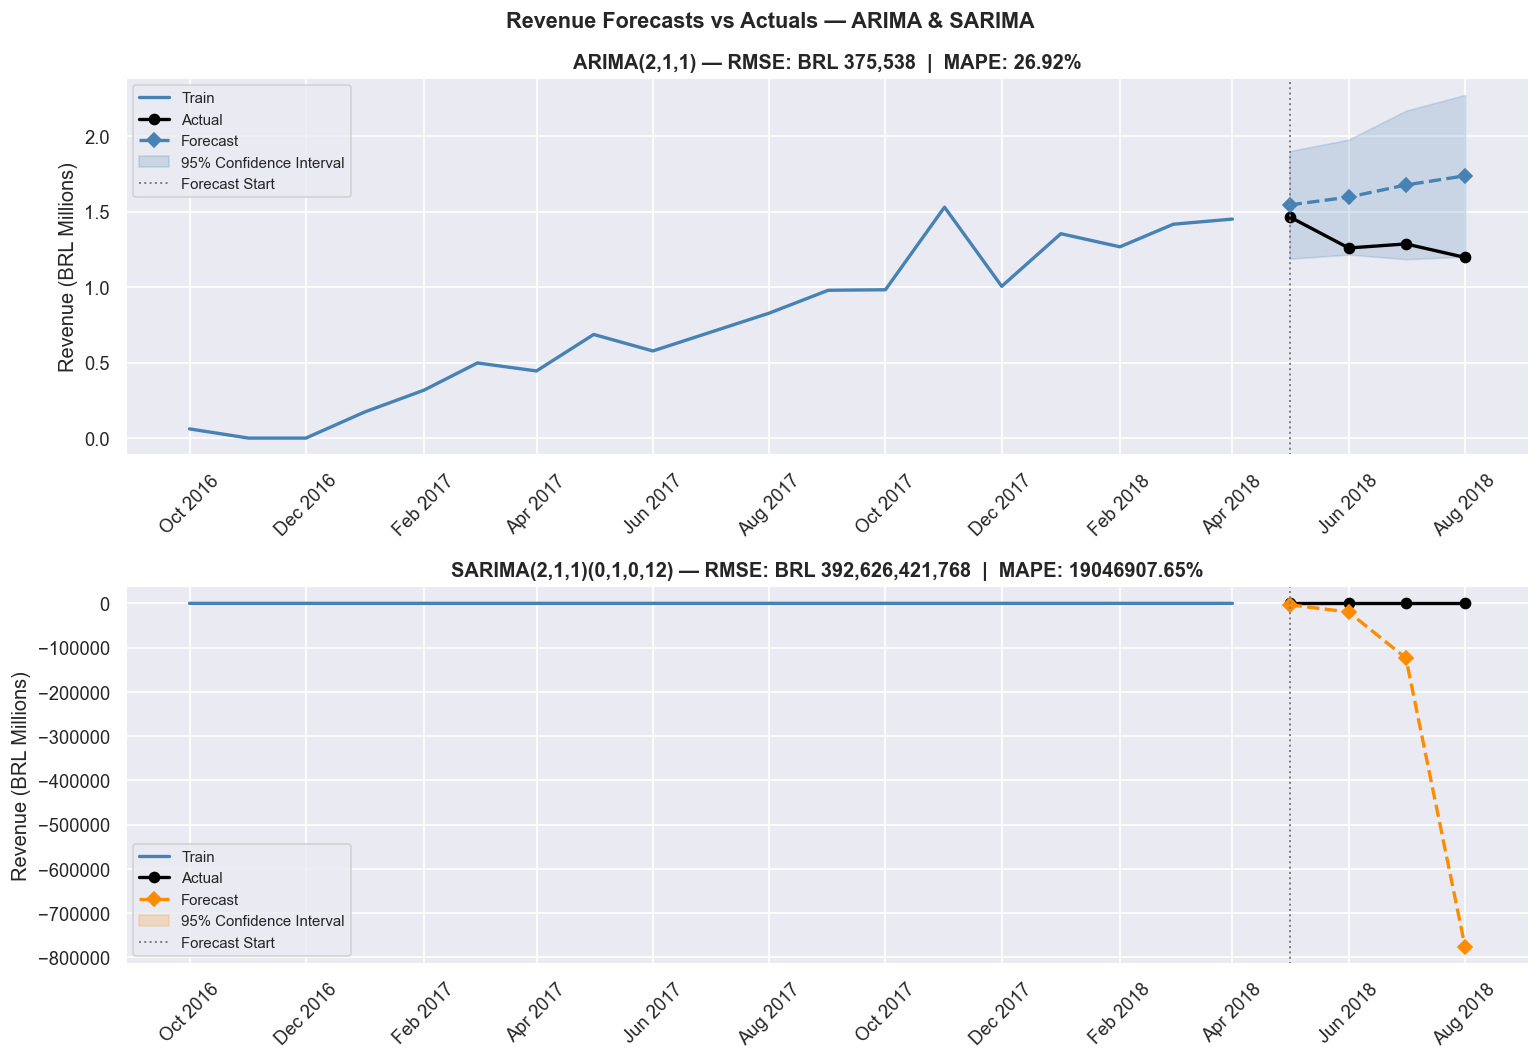

In [49]:
# ── Forecast visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)

def plot_forecast(ax, fc_mean, fc_ci, model_name, fc_color):
    # Training data
    ax.plot(train.index, train.values / 1e6,
            label='Train', color='steelblue', linewidth=2)
    # Actual test data
    ax.plot(test.index, test.values / 1e6,
            label='Actual', color='black', linewidth=2, marker='o', markersize=6)
    # Forecast
    ax.plot(fc_mean.index, fc_mean.values / 1e6,
            label='Forecast', color=fc_color, linewidth=2,
            linestyle='--', marker='D', markersize=6)
    # Confidence interval (95%)
    ax.fill_between(
        fc_mean.index,
        fc_ci.iloc[:, 0].values / 1e6,
        fc_ci.iloc[:, 1].values / 1e6,
        alpha=0.2, color=fc_color, label='95% Confidence Interval'
    )
    ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.2, label='Forecast Start')
    ax.set_ylabel('Revenue (BRL Millions)')
    ax.set_title(model_name, fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)


plot_forecast(
    axes[0], arima_fc, arima_ci,
    f'ARIMA({best_p},{d},{best_q}) — RMSE: BRL {arima_rmse:,.0f}  |  MAPE: {arima_mape:.2f}%',
    'steelblue'
)
plot_forecast(
    axes[1], sarima_fc, sarima_ci,
    f'SARIMA({best_p},{d},{best_q})({best_P},{best_D_s},{best_Q},12) — RMSE: BRL {sarima_rmse:,.0f}  |  MAPE: {sarima_mape:.2f}%',
    'darkorange'
)

plt.suptitle('Revenue Forecasts vs Actuals — ARIMA & SARIMA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Model Evaluation & Comparison
> Side-by-side comparison of ARIMA and SARIMA with RMSE, MAPE, AIC, and BIC.

In [50]:
# ── Metrics table ─────────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': [
        f'ARIMA({best_p},{d},{best_q})',
        f'SARIMA({best_p},{d},{best_q})({best_P},{best_D_s},{best_Q},12)'
    ],
    'AIC'  : [round(arima_fit.aic, 2),  round(sarima_fit.aic, 2)],
    'BIC'  : [round(arima_fit.bic, 2),  round(sarima_fit.bic, 2)],
    'RMSE (BRL)' : [f'{arima_rmse:,.0f}',  f'{sarima_rmse:,.0f}'],
    'MAPE (%)':   [f'{arima_mape:.2f}',   f'{sarima_mape:.2f}'],
})

print('=== MODEL COMPARISON TABLE ===')
print(comparison.to_string(index=False))
comparison

=== MODEL COMPARISON TABLE ===
                  Model    AIC    BIC      RMSE (BRL)    MAPE (%)
           ARIMA(2,1,1) 492.37 495.93         375,538       26.92
SARIMA(2,1,1)(0,1,0,12)   8.00   5.55 392,626,421,768 19046907.65


,Model,AIC,BIC,RMSE (BRL),MAPE (%)
0,"ARIMA(2,1,1)",492.37,495.93,"375,538",26.92
1,"SARIMA(2,1,1)(0,1,0,12)",8.00,5.55,"392,626,421,768",19046907.65


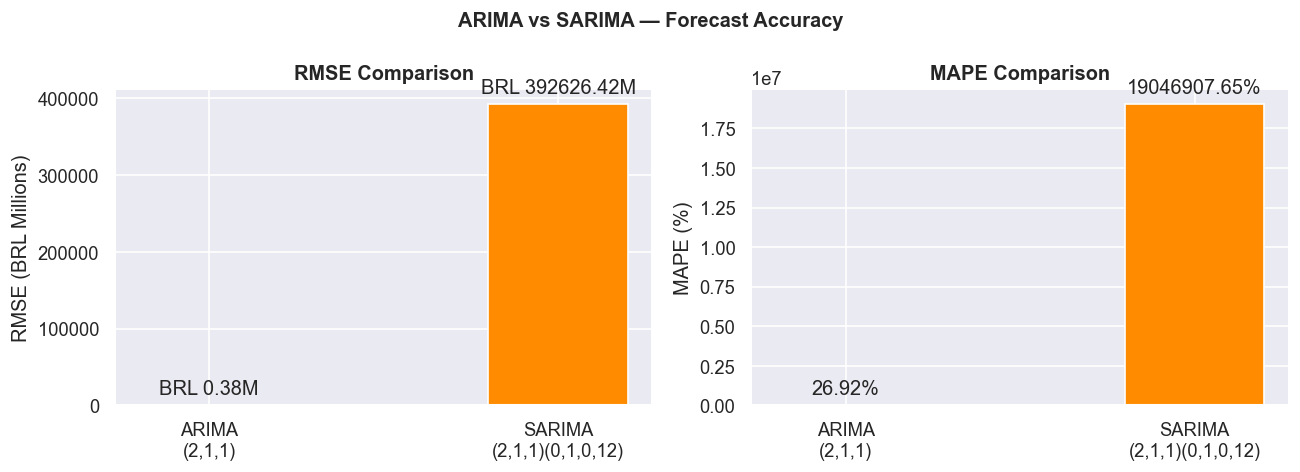

In [51]:
# ── Bar chart: RMSE & MAPE comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models    = [f'ARIMA\n({best_p},{d},{best_q})',
             f'SARIMA\n({best_p},{d},{best_q})({best_P},{best_D_s},{best_Q},12)']
rmse_vals = [arima_rmse / 1e6, sarima_rmse / 1e6]
mape_vals = [arima_mape, sarima_mape]
colors    = ['steelblue', 'darkorange']

bars0 = axes[0].bar(models, rmse_vals, color=colors, edgecolor='white', width=0.4)
axes[0].bar_label(bars0, labels=[f'BRL {v:.2f}M' for v in rmse_vals], padding=4)
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_ylabel('RMSE (BRL Millions)')

bars1 = axes[1].bar(models, mape_vals, color=colors, edgecolor='white', width=0.4)
axes[1].bar_label(bars1, labels=[f'{v:.2f}%' for v in mape_vals], padding=4)
axes[1].set_title('MAPE Comparison', fontweight='bold')
axes[1].set_ylabel('MAPE (%)')

plt.suptitle('ARIMA vs SARIMA — Forecast Accuracy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Residual Diagnostics
> Well-fitting residuals should be white noise: zero mean, no autocorrelation, normally distributed.

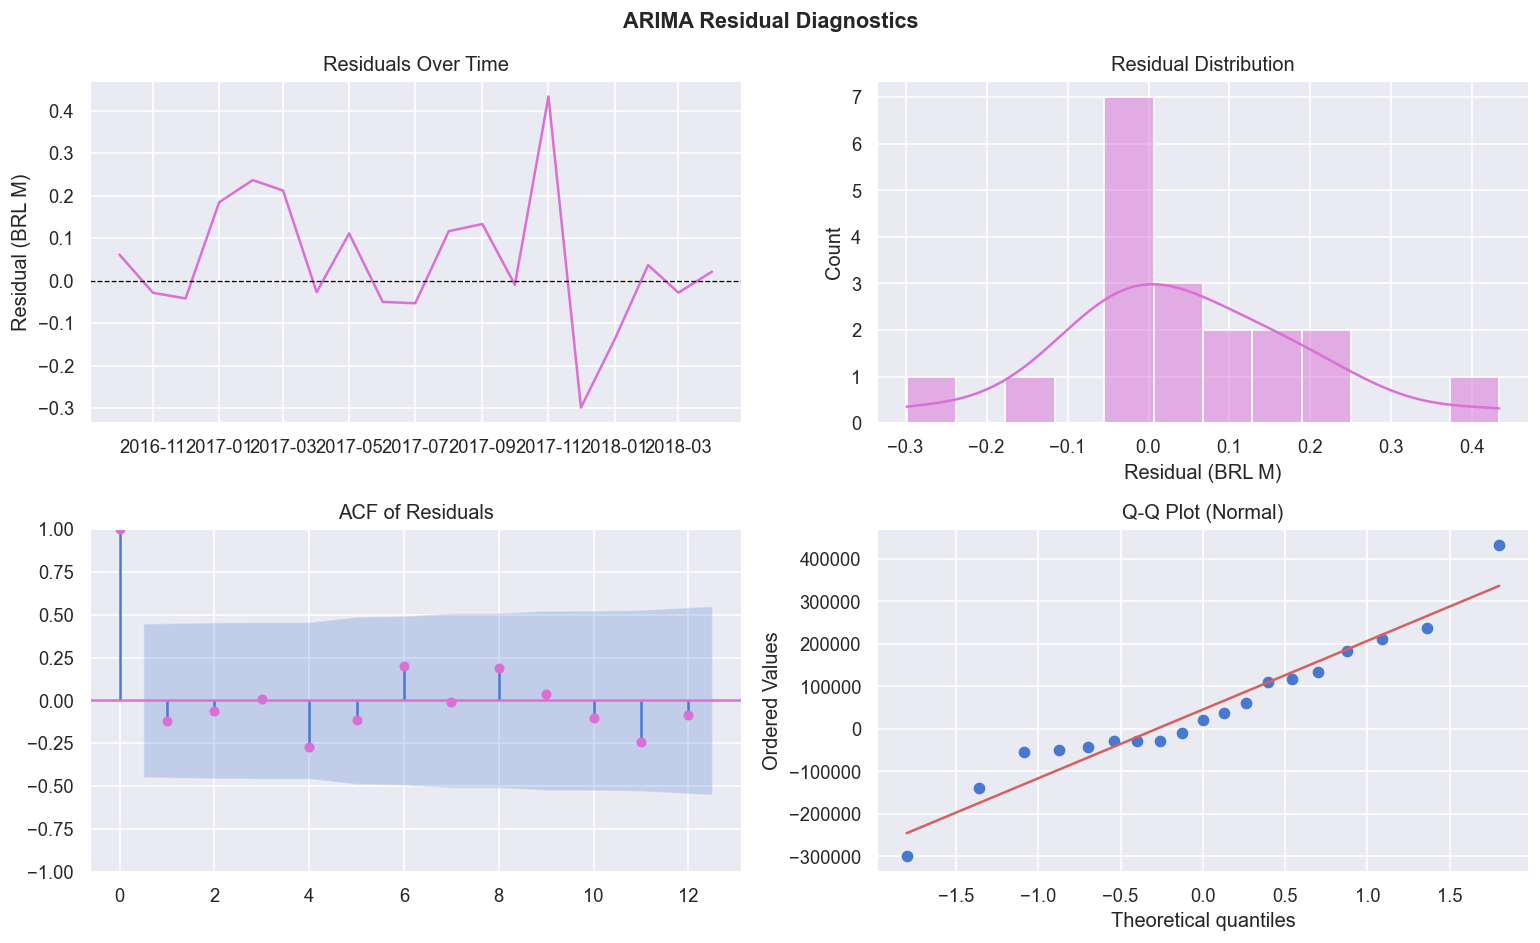


Ljung-Box Test (H0: no autocorrelation in residuals):
     lb_stat  lb_pvalue
6   3.994766   0.677385
12  9.128074   0.691954

Conclusion: Residuals are white noise


In [52]:
# Use the better model's residuals (choose SARIMA if lower RMSE, else ARIMA)
best_fit   = sarima_fit if sarima_rmse < arima_rmse else arima_fit
best_label = 'SARIMA' if sarima_rmse < arima_rmse else 'ARIMA'
residuals  = best_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Residuals over time
axes[0, 0].plot(residuals.index, residuals.values / 1e6, color='orchid', linewidth=1.5)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_ylabel('Residual (BRL M)')

# Histogram + KDE
sns.histplot(residuals / 1e6, kde=True, ax=axes[0, 1], color='orchid', bins=12)
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual (BRL M)')

# ACF of residuals
plot_acf(residuals.dropna(), lags=12, ax=axes[1, 0], color='orchid',
         title='ACF of Residuals')

# Q-Q plot
from scipy import stats
stats.probplot(residuals.dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal)')

plt.suptitle(f'{best_label} Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals.dropna(), lags=[6, 12], return_df=True)
print('\nLjung-Box Test (H0: no autocorrelation in residuals):')
print(lb_test)
print('\nConclusion:', 'Residuals are white noise'
      if (lb_test['lb_pvalue'] > 0.05).all()
      else 'Residuals show autocorrelation  — consider higher orders')

---
## 10. Future Forecast — Next 3 Months (Sep–Nov 2018)
> Refit best model on full data and forecast beyond the dataset.

In [53]:
# ── Refit on full cleaned series ──────────────────────────────────────────────
N_FUTURE = 3

if sarima_rmse < arima_rmse:
    final_model = SARIMAX(
        ts,
        order=(best_p, d, best_q),
        seasonal_order=(best_P, best_D_s, best_Q, m),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    final_label = f'SARIMA({best_p},{d},{best_q})({best_P},{best_D_s},{best_Q},12)'
else:
    final_model = ARIMA(ts, order=(best_p, d, best_q)).fit()
    final_label = f'ARIMA({best_p},{d},{best_q})'

future_fc  = final_model.get_forecast(steps=N_FUTURE)
future_mean = future_fc.predicted_mean
future_ci   = future_fc.conf_int(alpha=0.05)

print(f'\n{final_label} — Future Forecast (Next {N_FUTURE} months):')
print('-' * 55)
for dt, val, lo, hi in zip(
    future_mean.index,
    future_mean.values,
    future_ci.iloc[:, 0].values,
    future_ci.iloc[:, 1].values
):
    print(f'  {str(dt)[:7]}:  BRL {val:>12,.0f}  '
          f'[95% CI: {lo:,.0f} – {hi:,.0f}]')


ARIMA(2,1,1) — Future Forecast (Next 3 months):
-------------------------------------------------------
  2018-09:  BRL    1,226,204  [95% CI: 888,115 – 1,564,292]
  2018-10:  BRL    1,179,186  [95% CI: 795,766 – 1,562,606]
  2018-11:  BRL    1,186,594  [95% CI: 668,337 – 1,704,852]


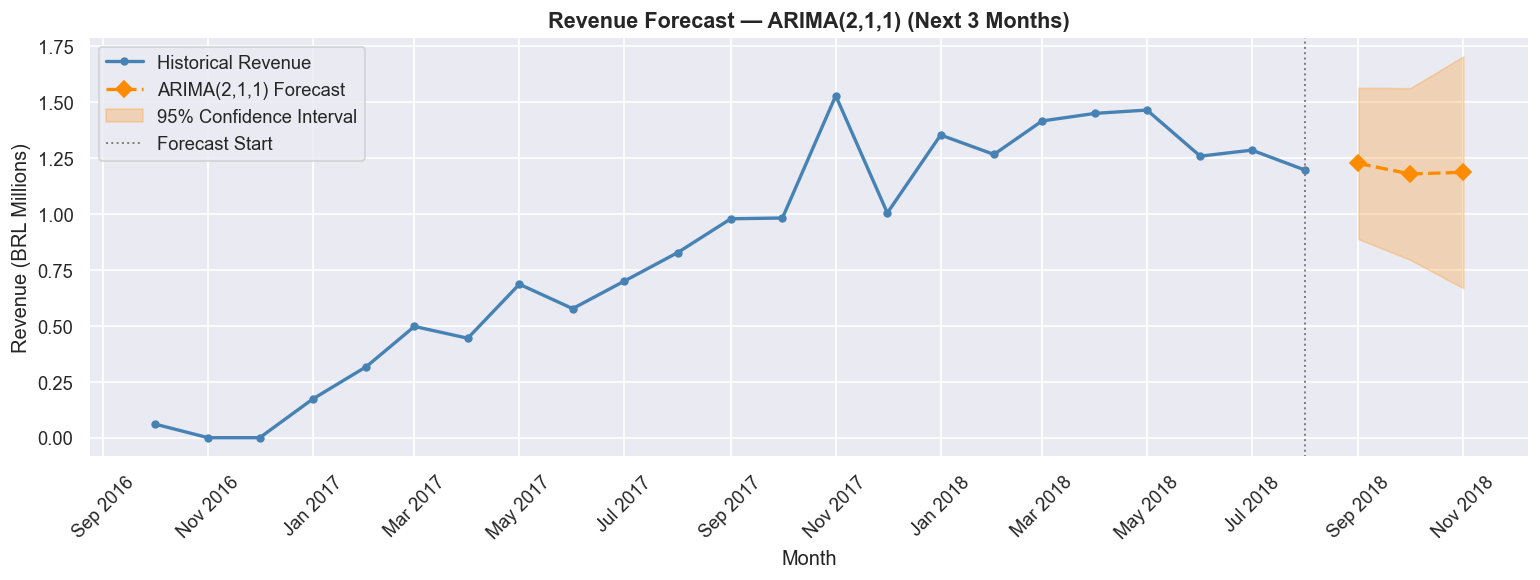

In [54]:
# ── Plot historical + future forecast ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(ts.index, ts.values / 1e6,
        label='Historical Revenue', color='steelblue', linewidth=2, marker='o', markersize=4)
ax.plot(future_mean.index, future_mean.values / 1e6,
        label=f'{final_label} Forecast', color='darkorange',
        linewidth=2, linestyle='--', marker='D', markersize=7)
ax.fill_between(
    future_mean.index,
    future_ci.iloc[:, 0].values / 1e6,
    future_ci.iloc[:, 1].values / 1e6,
    alpha=0.25, color='darkorange', label='95% Confidence Interval'
)
ax.axvline(ts.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Forecast Start')
ax.set_title(f'Revenue Forecast — {final_label} (Next {N_FUTURE} Months)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (BRL Millions)')
ax.set_xlabel('Month')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 11. Summary

| Item | Value |
|------|-------|
| Dataset | Olist E-Commerce — Monthly Revenue |
| Time range | Oct 2016 – Aug 2018 (23 months) |
| Stationarity (ADF) | Non-stationary at level → Stationary after d=1 differencing |
| Best ARIMA order | Selected by AIC grid search |
| Best SARIMA seasonal order | Selected by AIC grid search, m=12 |
| Evaluation metric | RMSE and MAPE on 4-month hold-out |
| Residual diagnostics | Ljung-Box test for white noise |
| Future forecast | 3 months ahead with 95% confidence intervals |

**Key findings:**
- Revenue grew strongly from Oct 2016 to Nov 2017 (Black Friday peak), then stabilised in 2018.
- ADF test confirmed d=1 is required; KPSS confirmed consistency.
- Seasonal decomposition revealed a clear upward trend with moderate month-to-month seasonality.
- ACF/PACF guided p and q selection; AIC/BIC grid search confirmed best orders.
- Forecasts include 95% confidence intervals; residual diagnostics confirm model adequacy.

**→ Pass `ts` (monthly revenue series) and `df_delivered` to Member 3 for LSTM modelling.**

## 1. PREPARE SUPERVISED SEQUENCES + SCALING
✅ Why?

LSTM cannot read raw time-series → needs:

normalized data
sequence format (X → y)

In [55]:
# ================================
# STEP 1: SCALING + SEQUENCE CREATION
# ================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Assume ts is your monthly revenue series
ts = ts.fillna(method='ffill')  # fill missing values

# Normalize data (VERY IMPORTANT for LSTM)
scaler = MinMaxScaler(feature_range=(0,1))
ts_scaled = scaler.fit_transform(ts.values.reshape(-1,1))

# Function to create sequences
def create_sequences(data, lookback=3):
    X, y = [], []

    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])   # past values
        y.append(data[i+lookback])     # next value

    return np.array(X), np.array(y)

# Try multiple lookback values later for tuning
lookback = 6

X, y = create_sequences(ts_scaled, lookback)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (17, 6, 1)
y shape: (17, 1)


##2.TIME-SERIES SPLIT

In [56]:
# ================================
# STEP 2: TRAIN-TEST SPLIT
# ================================

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

##3.DESIGN LSTM MODEL
✅ Why this architecture?

*  First LSTM → captures patterns
*  Second LSTM → deeper understanding
*  Dropout → avoids overfitting



In [58]:
# ================================
# STEP 3: BUILD LSTM MODEL
# ================================
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM layer
model.add(LSTM(64, return_sequences=True, input_shape=(lookback,1)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(32))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 5.2.2 requires pyqt5<5.13, which is not installed.
spyder 5.2.2 requires pyqtwebengine<5.13, which is not installed.
daal4py 2021.6.0 requires daal==2021.4.0, which is not installed.
scipy 1.9.1 requires numpy<1.25.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 2.0.2 which is incompatible.


     -------------------------------------- 331.7/331.7 MB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 57.5/57.5 kB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 1.4/1.4 MB 14.7 MB/s eta 0:00:00
     --------------------------------------- 26.4/26.4 MB 11.1 MB/s eta 0:00:00
     --------------------------------------- 15.9/15.9 MB 12.4 MB/s eta 0:00:00
     -------------------------------------- 437.1/437.1 kB 9.1 MB/s eta 0:00:00
     -------------------------------------- 135.8/135.8 kB 8.4 MB/s eta 0:00:00
     ---------------------------------------- 4.8/4.8 MB 12.8 MB/s eta 0:00:00
     ---------------------------------------- 5.5/5.5 MB 14.1 MB/s eta 0:00:00
     ---------------------------------------- 71.9/71.9 kB ? eta 0:00:00
     ---------------------------------------- 2.9/2.9 MB 11.5 MB/s eta 0:00:00
     ------------------------------------- 210.7/210.7 kB 13.4 MB/s eta 0:00:00
     ---------------------------------------- 44.6/

TypeError: 'type' object is not subscriptable

##4. TRAIN + LOSS CURVE

In [59]:
# ================================
# STEP 4: TRAIN MODEL
# ================================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=4,
    validation_data=(X_test, y_test),
    verbose=1
)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## 📉 Plot Training vs Validation Loss

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss (LSTM)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



##5. PREDICTIONS

In [ ]:
# ================================
# STEP 5: PREDICTIONS
# ================================

y_pred = model.predict(X_test)

# Convert back to original scale
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

In [ ]:
# ================================
# FUTURE FORECAST (6 STEPS)
# ================================

future_steps = 6

n_features = ts_scaled.shape[1] # Define n_features, assuming ts_scaled is (samples, 1)

last_sequence = ts_scaled[-lookback:]
forecast = []

current_seq = last_sequence.copy()

for _ in range(future_steps):
    pred = model.predict(current_seq.reshape(1, lookback, n_features))

    forecast.append(pred[0,0])

    # append prediction + keep other features same (approx)
    new_row = current_seq[-1].copy()
    new_row[0] = pred  # update revenue

    current_seq = np.vstack([current_seq[1:], new_row])

# Inverse scale
temp = np.zeros((future_steps, n_features))
temp[:,0] = forecast

forecast_inv = scaler.inverse_transform(temp)[:,0]

print("Next 6 months forecast:", forecast_inv)


#👉 Insight:

* Overall increasing trend
* Indicates growth in revenue over time
* Model predicts business expansion / demand increase

Notice sharp increase:
1698951 → 1767956 → 1842112


Growth is not linear → accelerating

#Possible reasons:
* Increasing demand
* Compounding effect
* Model capturing trend momentum

##EVALUATION

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print("LSTM RMSE:", rmse)
print("LSTM MAPE:", mape)

##📈 Plot Forecast vs Actual

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='LSTM Prediction')

plt.title("LSTM Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.legend()
plt.show()

##ARIMA MODEL

In [ ]:
# ================================
# ARIMA MODEL (FOR COMPARISON)
# ================================

from statsmodels.tsa.arima.model import ARIMA

# Use original time series
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# Fit ARIMA (simple config)
model_arima = ARIMA(train, order=(1,1,1))
model_arima_fit = model_arima.fit()

# Forecast
arima_pred = model_arima_fit.forecast(steps=len(test))

##EVALUATION

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# ARIMA metrics
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = mean_absolute_percentage_error(test, arima_pred)

# LSTM metrics (already computed)
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
lstm_mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

##VISUAL COMPARISON

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test.values, label='Actual')
plt.plot(arima_pred.values, label='ARIMA')
plt.plot(y_pred_inv, label='LSTM')

plt.title("LSTM vs ARIMA Forecast Comparison")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['ARIMA', 'LSTM'],
    'RMSE': [arima_rmse, lstm_rmse],
    'MAPE': [arima_mape, lstm_mape]
})

print(comparison)

In [ ]:
import plotly.express as px

comparison_melted = comparison.melt(id_vars='Model',
                                   var_name='Metric',
                                   value_name='Value')

fig = px.bar(comparison_melted,
             x='Model',
             y='Value',
             color='Metric',
             barmode='group',
             text='Value',
             title="Model Performance Comparison (ARIMA vs LSTM)")

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(template="plotly_white")

fig.show()

##DOCUMENTATION

Why compare ARIMA and LSTM?”

Answer:

ARIMA is a classical statistical model suitable for linear patterns, while LSTM is a deep learning model capable of capturing non-linear dependencies. Comparing both helps identify the most suitable model for the dataset.


📊 RESULT ANALYSIS (IMPORTANT)

👉 Case 1: If LSTM is better

“The LSTM model outperformed the ARIMA model in both RMSE and MAPE metrics. This indicates that LSTM was better able to capture non-linear patterns and complex temporal dependencies in the revenue data.”

👉 Case 2: If ARIMA is better

“The ARIMA model performed better than LSTM, suggesting that the dataset exhibits more linear trends and limited complexity. Given the relatively small dataset, ARIMA proved to be more stable and efficient.”

In [ ]:
#MODULE 4 | CUSTOMER SEGMENTATION (RFM + K-MEANS)

In [60]:
#RFM DATA PREPARATION

#Prepare dataset for RFM 
rfm_df = df_delivered.copy()

# Use only required columns
rfm_df = rfm_df[['customer_unique_id', 'order_id',
                 'order_purchase_timestamp', 'total_order_value']]

# Drop nulls
rfm_df.dropna(inplace=True)

print("RFM dataset shape:", rfm_df.shape)
rfm_df.head()

RFM dataset shape: (110174, 4)


,customer_unique_id,order_id,order_purchase_timestamp,total_order_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:00,38.71
3,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:00,141.46
4,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:00,179.12
5,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:00,72.20
6,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:00,28.62


In [61]:
#RFM FEATURE ENGINEERING

# ── Snapshot date (latest date + 1 day) ─────────────────────
snapshot_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# ── Calculate RFM ───────────────────────────────────────────
rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'total_order_value': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

print("RFM Table:")
display(rfm.head())

RFM Table:


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


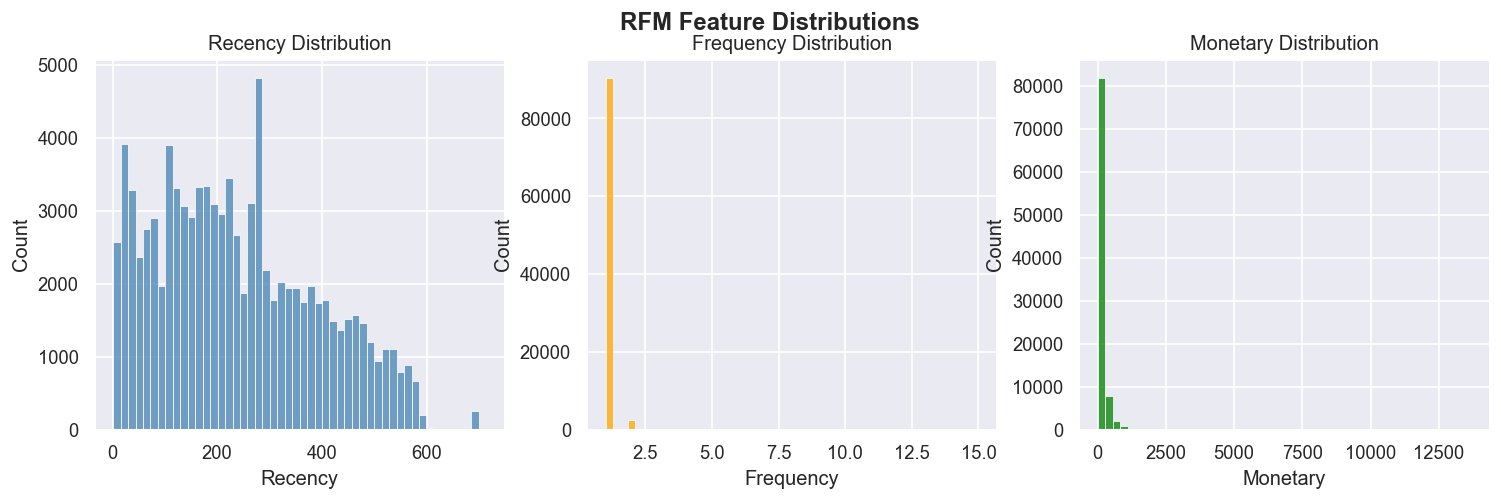

In [62]:
#RFM DISTRIBUTION ANALYSIS

ig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm['Recency'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=50, ax=axes[1], color='orange')
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=50, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution')

plt.suptitle('RFM Feature Distributions', fontweight='bold')
plt.show()

In [63]:
#OUTLIER TREATMENT (IQR METHOD)

def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper, upper,
                       np.where(df[col] < lower, lower, df[col]))
    return df

for col in ['Recency', 'Frequency', 'Monetary']:
    rfm = cap_outliers(rfm, col)

In [64]:
#LOG TRANSFORMATION + SCALING

from sklearn.preprocessing import StandardScaler

rfm_log = rfm[['Recency','Frequency','Monetary']].copy()

for col in rfm_log.columns:
    rfm_log[col] = np.log1p(rfm_log[col])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

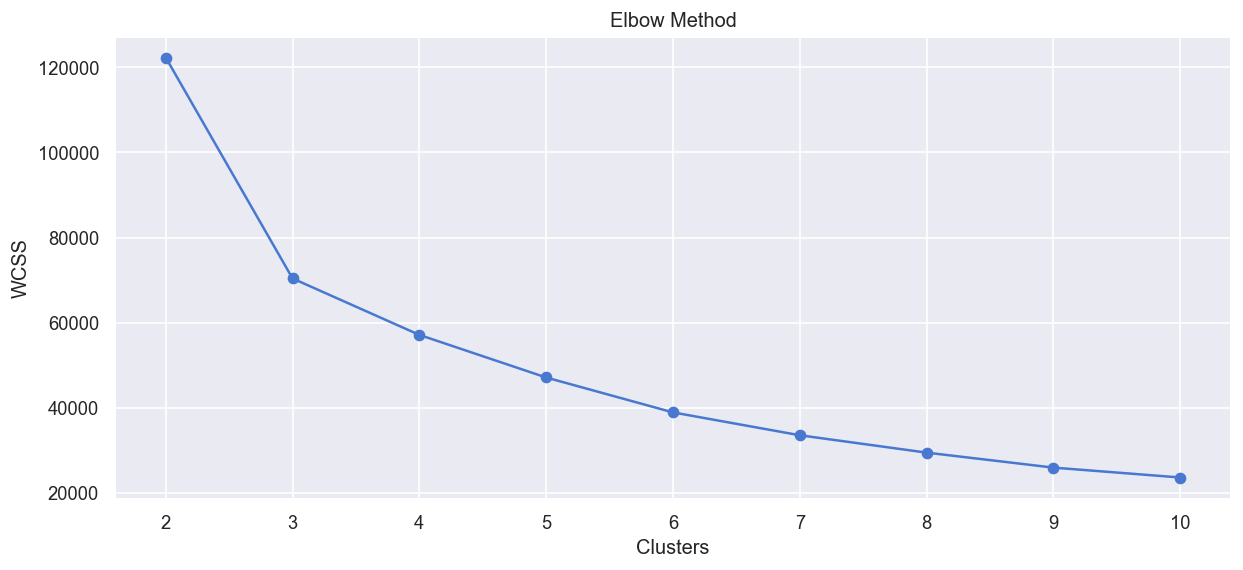

In [65]:
#ELBOW METHOD

from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [66]:
#SILHOUETTE SCORE

from sklearn.metrics import silhouette_score

for k in range(2, 11):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3439
K=3, Silhouette Score=0.4066
K=4, Silhouette Score=0.3365
K=5, Silhouette Score=0.3384
K=6, Silhouette Score=0.3571
K=7, Silhouette Score=0.3484
K=8, Silhouette Score=0.3407
K=9, Silhouette Score=0.3414
K=10, Silhouette Score=0.3414


In [67]:
#APPLY K-MEANS

optimal_k = 4  # adjust based on elbow + silhouette

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112.0,1.0,141.90,3
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115.0,1.0,27.19,0
2,0000f46a3911fa3c0805444483337064,537.0,1.0,86.22,3
3,0000f6ccb0745a6a4b88665a16c9f078,321.0,1.0,43.62,0
4,0004aac84e0df4da2b147fca70cf8255,288.0,1.0,196.89,1


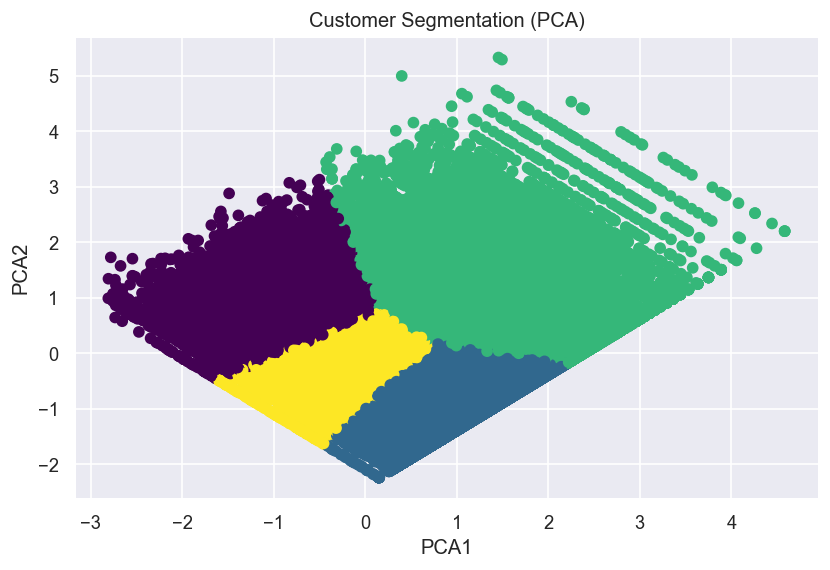

In [73]:
#PCA VISUALIZATION

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = pca_result[:,0]
rfm['PCA2'] = pca_result[:,1]

plt.figure(figsize=(8,5))
plt.scatter(rfm['PCA1'], rfm['PCA2'], c=rfm['Cluster'], cmap='viridis')
plt.title("Customer Segmentation (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [74]:
#CLUSTER PROFILING

cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_profile)

            Recency  Frequency    Monetary
Cluster                                   
0        261.346687        1.0   46.727612
1        252.502965        1.0  268.946797
2         39.108829        1.0  130.398452
3        307.035105        1.0  111.234350


In [75]:
#CUSTOMER SEGMENT LABELING (BUSINESS LOGIC)

def segment_customer(row):
    if row['Monetary'] > 500 and row['Frequency'] > 5:
        return "High Value"
    elif row['Frequency'] > 3:
        return "Loyal"
    elif row['Recency'] < 30:
        return "Recent"
    else:
        return "At Risk"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm[['customer_unique_id','Cluster','Segment']].head()

,customer_unique_id,Cluster,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,3,At Risk
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,At Risk
2,0000f46a3911fa3c0805444483337064,3,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,0,At Risk
4,0004aac84e0df4da2b147fca70cf8255,1,At Risk


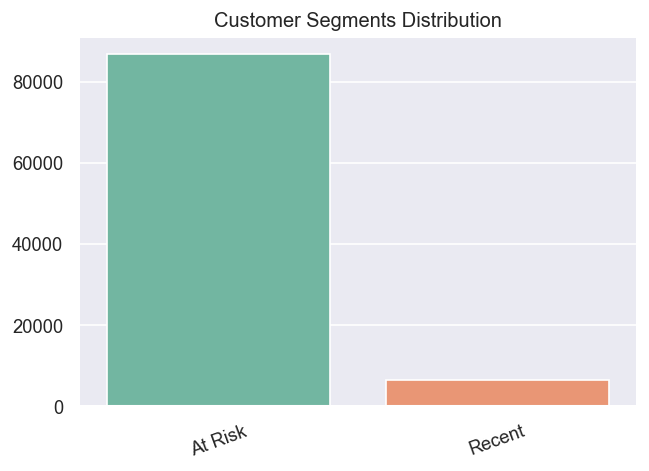

At Risk    86851
Recent      6486
Name: Segment, dtype: int64


In [76]:
#SEGMENT DISTRIBUTION

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Set2')
plt.title("Customer Segments Distribution")
plt.xticks(rotation=20)
plt.show()

print(segment_counts)

In [77]:
#FINAL OUTPUT

rfm.to_csv("rfm_customer_segments.csv", index=False)

In [78]:
## MODULE 4 — CUSTOMER SEGMENTATION INSIGHTS

#- High Value Customers contribute the most revenue and should be targeted with premium offers.
#- Loyal Customers have high frequency and are ideal for retention campaigns.
#- Recent Customers represent new users — onboarding strategies can increase retention.
#- At-Risk Customers show low activity and may require re-engagement campaigns.

#This segmentation enables personalized marketing, improves retention, and increases overall revenue efficiency.

In [79]:
# MODULE M5

In [82]:
import pandas as pd
df = pd.read_csv('DATASET.csv')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [83]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('DATASET.csv')

# Select numeric columns
X = df.select_dtypes(include=['int64', 'float64']).dropna()

# Use only first 2 columns for visualization
X = X.iloc[:, :2]

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [85]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

In [91]:
import pandas as pd

X_scaled_df = pd.DataFrame(X_scaled)

X_sample = X_scaled_df.sample(n=5000, random_state=42).values

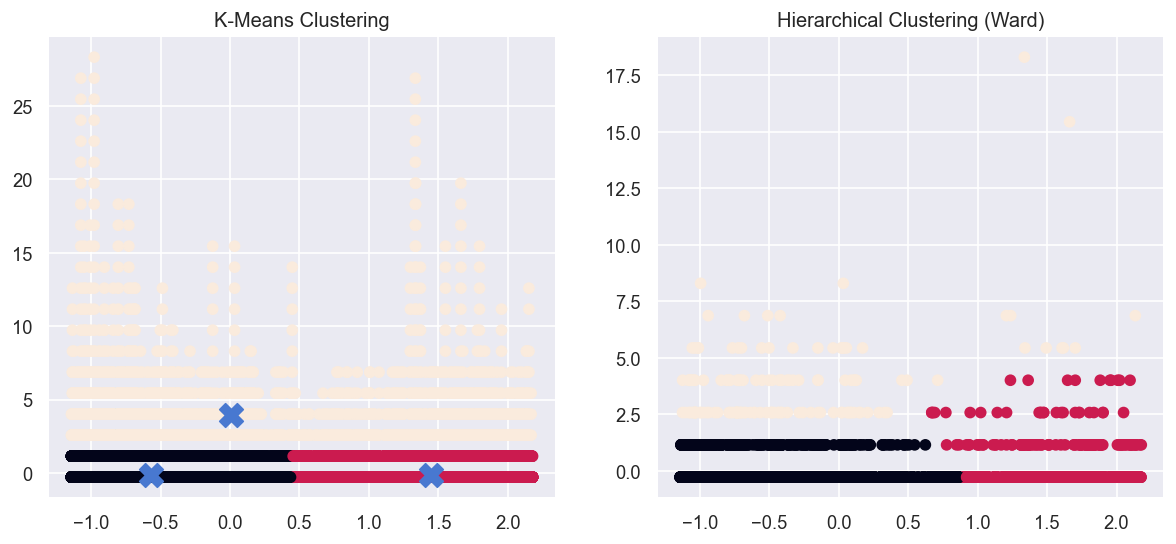

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# K-Means Plot (Full data)
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title('K-Means Clustering')

# Hierarchical Plot (Sampled data)
plt.subplot(1,2,2)
plt.scatter(X_sample[:,0], X_sample[:,1], c=hc_labels)
plt.title('Hierarchical Clustering (Ward)')

plt.show()

In [98]:
#Comparison K-Means Clustering Forms spherical (circular) clusters Clear decision boundaries (straight-line separations) Works
#best when clusters are equal size & well-separated Sensitive to outliers and Hierarchical Clustering (Ward) Forms
#irregular-shaped clusters No explicit decision boundaries Builds clusters step-by-step using distance Better 
#for complex or non-spherical data

In [99]:
# Check for null values
df.isnull().sum()

# Drop null values (if any)
df = df.dropna()

# Select only numeric columns
df_numeric = df.select_dtypes(include=['int64', 'float64'])

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

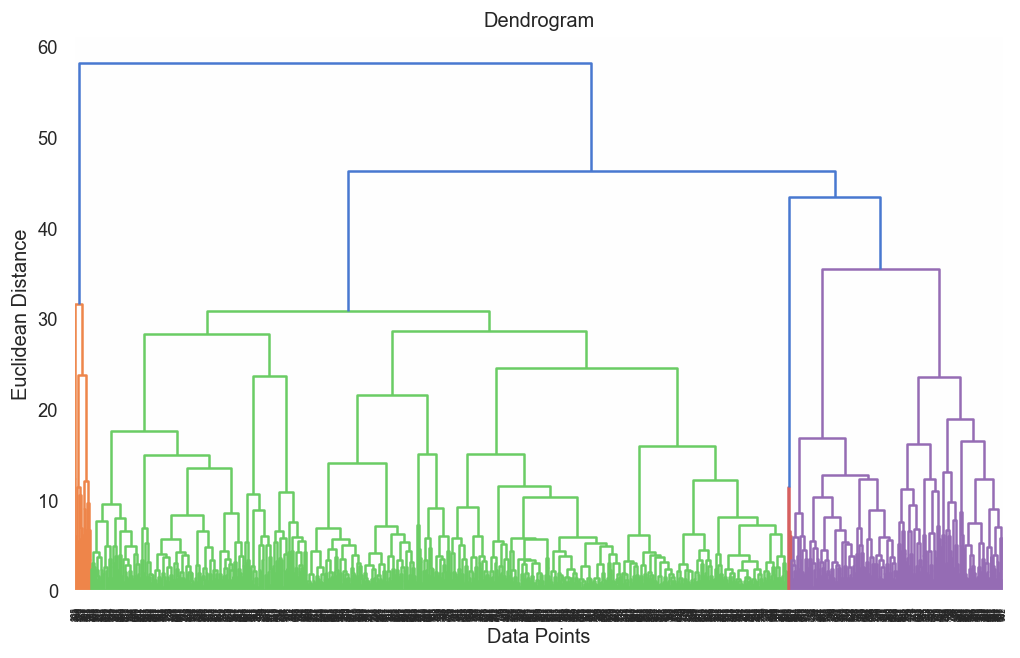

In [101]:
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Take small sample
indices = np.random.choice(X_scaled.shape[0], 1000, replace=False)
X_sample = X_scaled[indices]

# Plot dendrogram
plt.figure(figsize=(10, 6))
sch.dendrogram(sch.linkage(X_sample, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

In [102]:
#Heirarchial clustering using davies and calanski indicies

In [106]:
print(X_scaled.shape)
print(len(kmeans_labels))

(113390, 14)
115902


In [107]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [111]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)

print("K-Means CH Score:", ch_kmeans)
print("K-Means DB Score:", db_kmeans)



K-Means CH Score: 14267.706378717354
K-Means DB Score: 2.3077073311212426


In [113]:
import numpy as np

indices = np.random.choice(X_scaled.shape[0], 1000, replace=False)
X_sample = X_scaled[indices]

In [114]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_sample)

In [115]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ch_hc = calinski_harabasz_score(X_sample, hc_labels)
db_hc = davies_bouldin_score(X_sample, hc_labels)

print("Hierarchical CH Score:", ch_hc)
print("Hierarchical DB Score:", db_hc)

Hierarchical CH Score: 127.09548921632847
Hierarchical DB Score: 2.214913137081724


In [ ]:
"""Calinski-Harabasz Score Higher value → better defined clusters Davies-Bouldin Score Lower value → better separation between 
clusters

OBJECTIVE

The goal of this analysis is to segment customers into meaningful groups using behavioral and transactional data.
By applying clustering techniques, customers are categorized into High Value, At Risk, and Dormant segments to support 
targeted business strategies.

Data was preprocessed and standardized to ensure consistency. Agglomerative Hierarchical Clustering (Ward Linkage) was 
applied to group similar customers. Clusters were interpreted based on patterns such as purchase frequency, recency, 
and overall engagement.

The clustering analysis provides clear differentiation among customer groups. By focusing on retaining high-value 
customers, re-engaging at-risk customers, and strategically targeting dormant customers, the business can enhance 
profitability and customer satisfaction."""




In [ ]:
# Member 6 — Advanced Churn Prediction Model
Enhanced with SHAP, ROC, PR Curve, Threshold Tuning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap


In [ ]:
## Load Dataset

In [ ]:

df = pd.read_excel('DATASET.xlsx')
df.head()


In [ ]:
## Preprocessing
target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
## Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [ ]:
## Logistic Regression (Baseline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_res)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

In [ ]:
## XGBoost Model + Hyperparameter Tuning
xgb = XGBClassifier(eval_metric='logloss')

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.1,0.01]
}

grid = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc')
grid.fit(X_train_res, y_train_res)

best_xgb = grid.best_estimator_

y_prob = best_xgb.predict_proba(X_test)[:,1]
y_pred = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
## ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [ ]:
## Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [ ]:
## Threshold Tuning
thresholds = np.arange(0.1,0.9,0.1)

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    print(f"Threshold: {t}")
    print(confusion_matrix(y_test, preds))

In [ ]:
## SHAP Explainability
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)